# Super-Convergence

Воспроизводим идею [Smith и Topin](https://arxiv.org/abs/1708.07120): большой learning rate и один цикл его изменения могут ускорить обучение. Затем проверяем перенос на CIFAR-10, связь с регуляризацией и применение в RL.

Три seed: 17, 42, 103. В таблицах — среднее ± стандартное отклонение между ними. Время включает обучение, без валидации, графиков и подбора параметров. Индивидуальные панели показывают последний seed, сравнительные графики — все три.

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from train import load_data, train
from live import LivePlot

seeds = [17, 42, 103]

torch.set_num_threads(4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
data = load_data(device)
{name: len(labels) for name, (_, labels) in data.items()}

{'train': 55000, 'validation': 5000, 'test': 10000}

## Часть 1. Воспроизведение идеи на MNIST

**Что делаем:** сравниваем baseline на 85 эпохах, его срез на 12-й эпохе и два 1cycle на 12 эпохах с пиками LR 0,02 и 0,1.

**Гипотеза:** большой пик LR позволит получить близкую точность за меньшее число эпох. Ожидаем, что 1cycle с пиком 0,1 обойдет короткий baseline и приблизится к длинному.

CNN типа LeNet; 55 000 train / 5000 validation / 10 000 test. SGD, batch size=512, weight decay=0,0005. Начальный LR=0,01; momentum baseline=0,9, у 1cycle — 0,95 → 0,8 → 0,95.

In [ ]:
mnist_runs = {}


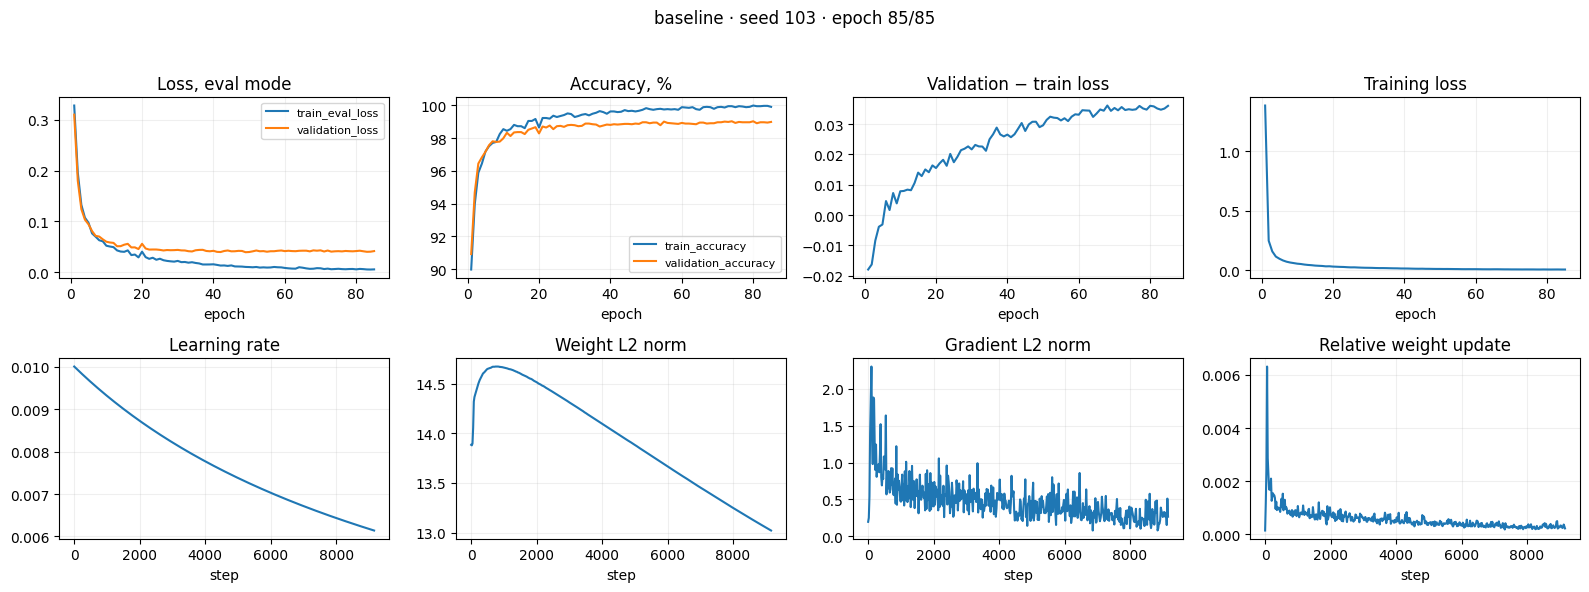

baseline, seed=17, epoch=1: val=89.46%, train=0.8s
baseline, seed=17, epoch=5: val=97.24%, train=3.1s
baseline, seed=17, epoch=10: val=98.28%, train=6.7s
baseline, seed=17, epoch=15: val=98.56%, train=10.0s
baseline, seed=17, epoch=20: val=98.66%, train=13.5s
baseline, seed=17, epoch=25: val=98.74%, train=17.0s
baseline, seed=17, epoch=30: val=98.84%, train=20.5s
baseline, seed=17, epoch=35: val=98.70%, train=24.0s
baseline, seed=17, epoch=40: val=98.96%, train=26.8s
baseline, seed=17, epoch=45: val=98.92%, train=30.5s
baseline, seed=17, epoch=50: val=98.90%, train=33.8s
baseline, seed=17, epoch=55: val=98.96%, train=37.4s
baseline, seed=17, epoch=60: val=98.94%, train=40.7s
baseline, seed=17, epoch=65: val=98.82%, train=43.9s
baseline, seed=17, epoch=70: val=98.98%, train=47.7s
baseline, seed=17, epoch=75: val=98.90%, train=50.6s
baseline, seed=17, epoch=80: val=99.08%, train=54.4s
baseline, seed=17, epoch=85: val=99.08%, train=57.5s
baseline, seed=42, epoch=1: val=89.28%, train=0.7s


In [ ]:
name = 'baseline'
mnist_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(data, name=name, seed=seed, live=live, epochs=85, max_lr=None, output="results/notebook")
    mnist_runs[name].append((history.assign(method=name, seed=seed), scores))


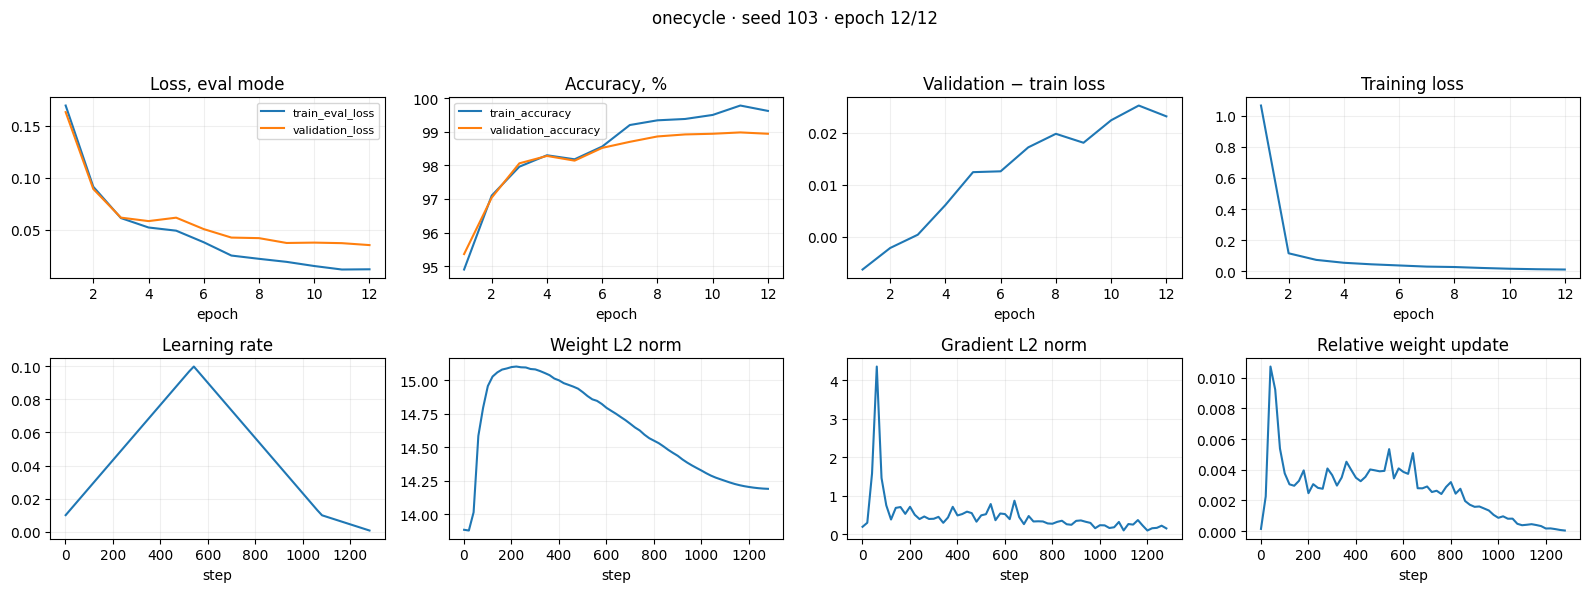

onecycle, seed=17, epoch=1: val=95.38%, train=0.6s
onecycle, seed=17, epoch=5: val=98.48%, train=3.6s
onecycle, seed=17, epoch=10: val=98.96%, train=6.7s
onecycle, seed=17, epoch=12: val=99.00%, train=8.3s
onecycle, seed=42, epoch=1: val=94.38%, train=0.7s
onecycle, seed=42, epoch=5: val=98.58%, train=3.3s
onecycle, seed=42, epoch=10: val=99.04%, train=7.0s
onecycle, seed=42, epoch=12: val=99.02%, train=8.3s
onecycle, seed=103, epoch=1: val=95.36%, train=0.6s
onecycle, seed=103, epoch=5: val=98.14%, train=3.3s
onecycle, seed=103, epoch=10: val=98.94%, train=7.0s
onecycle, seed=103, epoch=12: val=98.94%, train=8.3s


In [ ]:
name = 'onecycle'
mnist_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(data, name=name, seed=seed, live=live, epochs=12, max_lr=0.1, output="results/notebook")
    mnist_runs[name].append((history.assign(method=name, seed=seed), scores))


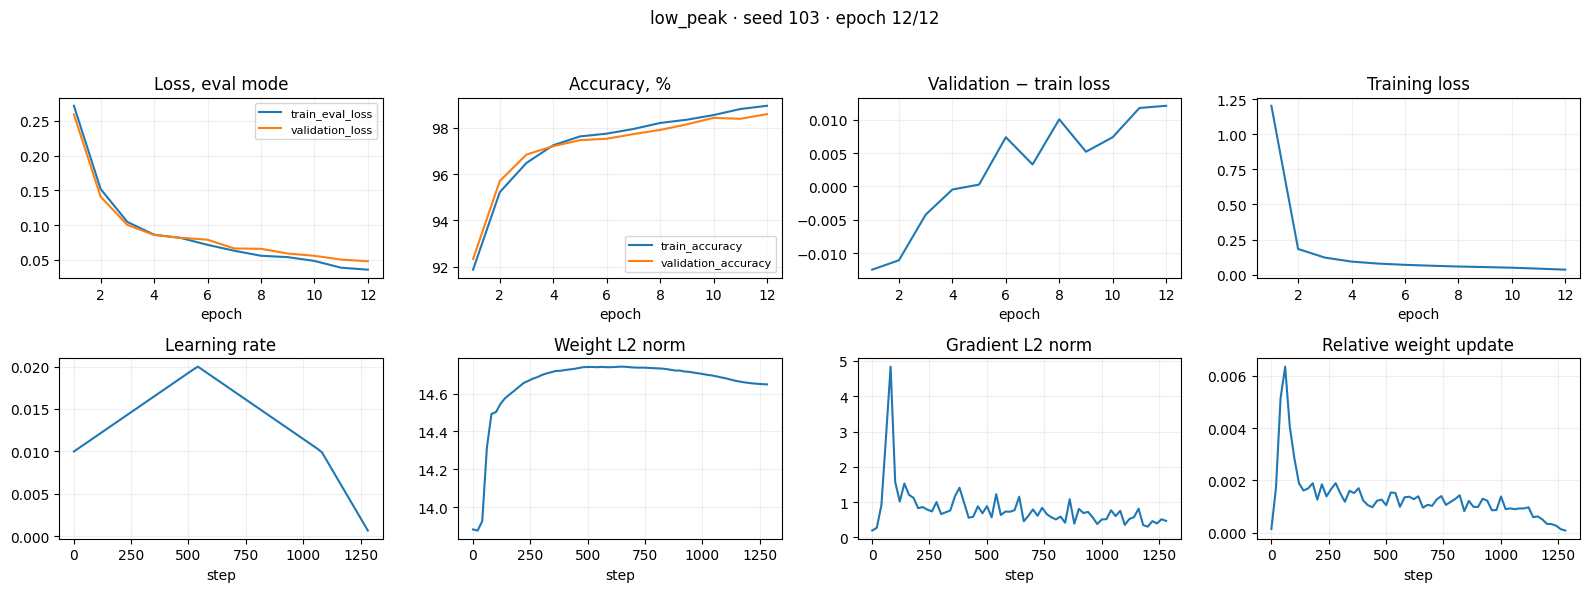

low_peak, seed=17, epoch=1: val=92.90%, train=0.8s
low_peak, seed=17, epoch=5: val=97.56%, train=3.6s
low_peak, seed=17, epoch=10: val=98.38%, train=6.7s
low_peak, seed=17, epoch=12: val=98.58%, train=8.2s
low_peak, seed=42, epoch=1: val=92.08%, train=0.8s
low_peak, seed=42, epoch=5: val=97.72%, train=3.8s
low_peak, seed=42, epoch=10: val=98.22%, train=7.4s
low_peak, seed=42, epoch=12: val=98.54%, train=8.9s
low_peak, seed=103, epoch=1: val=92.34%, train=0.7s
low_peak, seed=103, epoch=5: val=97.46%, train=3.2s
low_peak, seed=103, epoch=10: val=98.42%, train=6.6s
low_peak, seed=103, epoch=12: val=98.58%, train=8.1s


In [ ]:
name = 'low_peak'
mnist_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(data, name=name, seed=seed, live=live, epochs=12, max_lr=0.02, output="results/notebook")
    mnist_runs[name].append((history.assign(method=name, seed=seed), scores))


In [ ]:
histories = pd.concat([h for runs in mnist_runs.values() for h, _ in runs], ignore_index=True)
results = pd.concat([s for runs in mnist_runs.values() for _, s in runs], ignore_index=True)


In [ ]:
results.groupby("method").agg(
    accuracy=("test_accuracy", "mean"),
    std=("test_accuracy", "std"),
    seconds=("train_seconds", "mean"),
).round(3)

,accuracy,std,seconds
method,,,
baseline,99.053,0.055,58.286
baseline_12,98.500,0.120,8.427
low_peak,98.827,0.021,8.371
onecycle,99.127,0.015,8.315


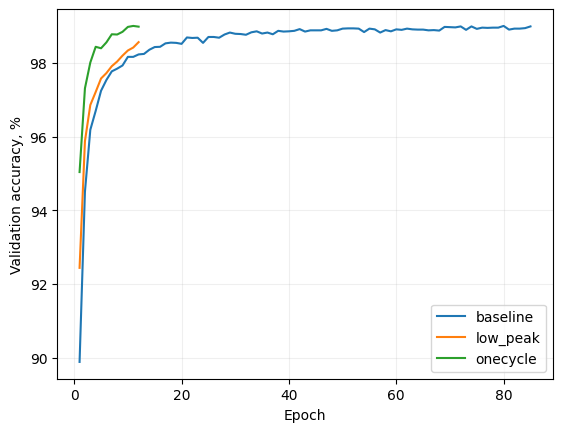

In [ ]:
for name, group in histories.groupby("method"):
    curve = group.groupby("epoch").validation_accuracy.mean()
    plt.plot(curve.index, curve, label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy, %")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Результат

| Режим | Эпохи | Test accuracy, % | Test CE | Обучение, с |
| --- | --- | --- | --- | --- |
| Baseline, 85 эпох | 85 | 99,053 ± 0,055 | 0,0279 ± 0,0008 | 58,29 ± 0,81 |
| Baseline, срез на 12-й эпохе | 12 | 98,500 ± 0,120 | 0,0451 ± 0,0022 | 8,43 ± 0,35 |
| 1cycle, пик 0,1 | 12 | 99,127 ± 0,015 | 0,0249 ± 0,0011 | 8,31 ± 0,05 |
| 1cycle, пик 0,02 | 12 | 98,827 ± 0,021 | 0,0360 ± 0,0007 | 8,37 ± 0,43 |

1cycle достигает 99,127% за 12 эпох против 99,053% за 85 у baseline — **7,01× быстрее** по времени обучения. При одинаковых 12 эпохах выигрыш равен **0,627 п.п.** Уменьшение пика до 0,02 снижает точность на 0,300 п.п. Здесь идея быстрого обучения с большим LR сработала.

### Loss и нормы

Сравниваем train и validation loss в режиме eval. Нормы относятся к весам линейных слоев и сверток; RMS — норма слоя, деленная на корень из числа его весов. Градиент измеряется до weight decay, относительное обновление — с учетом LR, momentum и decay. Диагностика записывается раз в 20 шагов; конечная норма — последняя сохраненная точка.

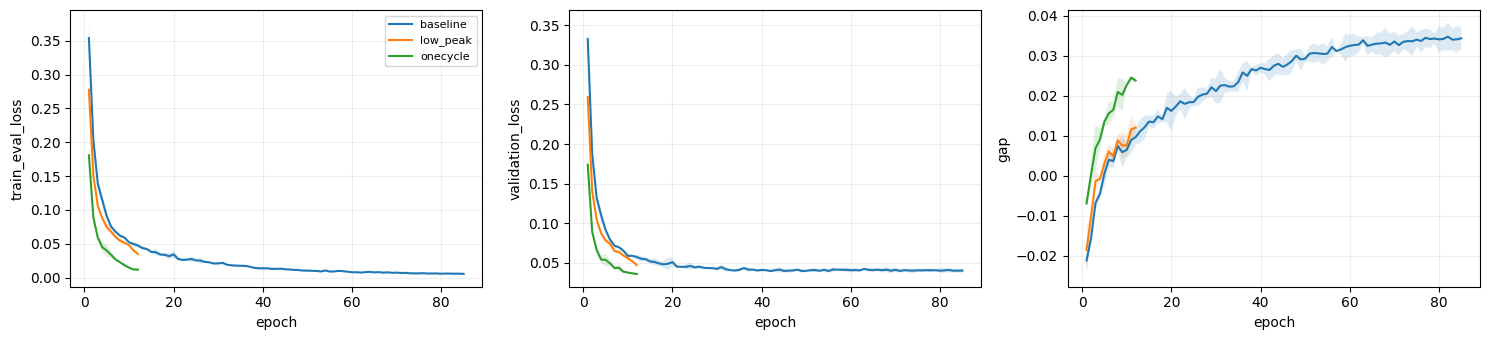

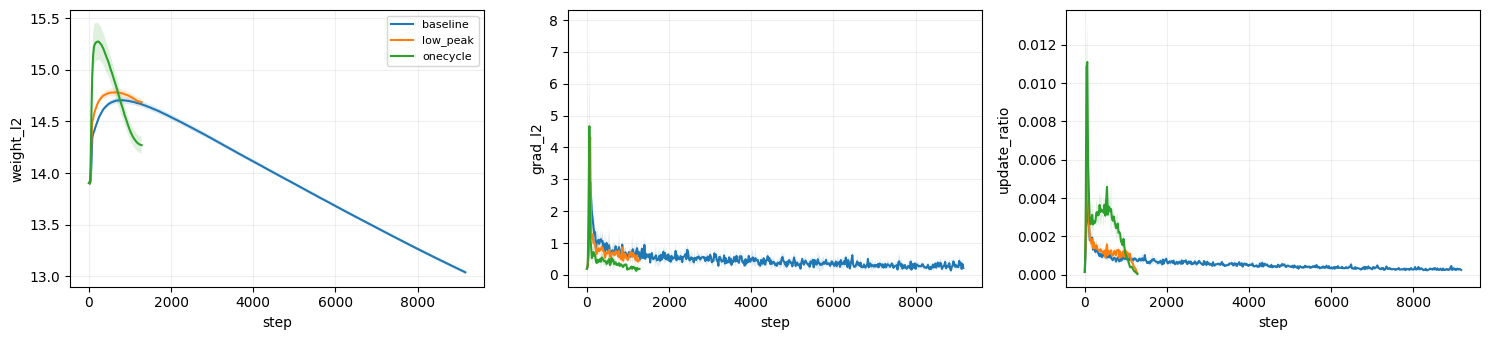

In [ ]:
from pathlib import Path

def plot_curves(frame, x, columns):
    fig, axes = plt.subplots(1, len(columns), figsize=(5 * len(columns), 3.5), squeeze=False)
    for axis, column in zip(axes[0], columns):
        for name, group in frame.groupby("method"):
            curve = group.groupby(x)[column].agg(["mean", "std"])
            axis.plot(curve.index, curve["mean"], label=name)
            axis.fill_between(curve.index, curve["mean"] - curve["std"].fillna(0), curve["mean"] + curve["std"].fillna(0), alpha=0.15)
        axis.set(xlabel=x, ylabel=column)
        axis.grid(alpha=0.2)
    axes[0, 0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def read_diagnostics(folder):
    return pd.concat([pd.read_csv(p).assign(method=p.parent.parent.name, seed=int(p.parent.name))
                      for p in Path(folder).glob("*/*/diagnostics.csv")], ignore_index=True)

plot_curves(histories, "epoch", ["train_eval_loss", "validation_loss", "gap"])
plot_curves(read_diagnostics("results/notebook"), "step", ["weight_l2", "grad_l2", "update_ratio"])

| Режим | Train CE | Validation CE | Gap | Конечная ‖W‖₂ | Макс. обновление, % |
| --- | --- | --- | --- | --- | --- |
| Baseline, 85 эпох | 0,0055 | 0,0399 | 0,0343 | 13,039 ± 0,018 | 0,601 |
| 1cycle, пик 0,1 | 0,0118 | 0,0356 | 0,0238 | 14,270 ± 0,081 | 1,181 |
| 1cycle, пик 0,02 | 0,0347 | 0,0467 | 0,0121 | 14,686 ± 0,038 | 0,657 |

У 1cycle train loss выше, чем у baseline, зато validation loss и gap ниже. Это согласуется с меньшим переобучением, хотя здесь отличаются и число эпох, и momentum. Самый маленький gap у low peak, но точность хуже — минимальный gap не означает лучший результат. Норма весов у основного 1cycle тоже выше, чем у baseline: 14,270 против 13,039.

## Часть 2. CIFAR-10 и ResNet

**Что делаем:** подбираем пик LR, weight decay и форму 1cycle на seed=17 по validation. Затем сравниваем выбранный 1cycle с cosine при одинаковых 20 эпохах на трех seed; прежние запуски на 50 эпохах оставляем ориентиром.

**Гипотеза:** исходный короткий цикл был недостаточно настроен. Ожидаем улучшения после подбора и преимущества над cosine при равном бюджете.

ResNet-20; 45 000 train / 5000 validation / 10 000 test, crop и flip при обучении. SGD, batch size=128. Подбор не использует test.

### Подбор параметров

Все варианты — 20 эпох и seed=17. Выбираем максимальную финальную validation accuracy; при равенстве — меньший validation loss. Начальный LR у 1cycle равен пику / 10. Основной цикл трехфазный; дополнительно проверен двухфазный с разогревом 30% бюджета.

| Режим | Начальный LR / пик | Weight decay | Validation accuracy, % |
| --- | --- | --- | --- |
| Cosine | 0,1 | 0,0001 | 88,80 |
| Cosine | 0,1 | 0,0005 | 90,08 |
| 1cycle, 3 фазы | 0,2 | 0,0001 | 89,74 |
| 1cycle, 3 фазы | 0,2 | 0,0005 | 90,30 |
| 1cycle, 2 фазы | 0,4 | 0,0001 | 89,80 |
| 1cycle, 3 фазы | 0,4 | 0,0001 | 90,56 |
| 1cycle, 3 фазы | 0,4 | 0,0005 | 90,44 |
| 1cycle, 3 фазы | 0,8 | 0,0001 | 89,54 |
| 1cycle, 3 фазы | 0,8 | 0,0005 | 89,00 |

Выбраны cosine с decay=0,0005 и 1cycle с пиком 0,4 и decay=0,0001. У исходного 1cycle пик был 0,2. Результаты подбора и кривые сохранены в `cifar_search.csv`; test при выборе не использовался. Выбранный 1cycle дополнительно обучен на seed 42 и 103, для seed 17 оценены сохраненные веса.

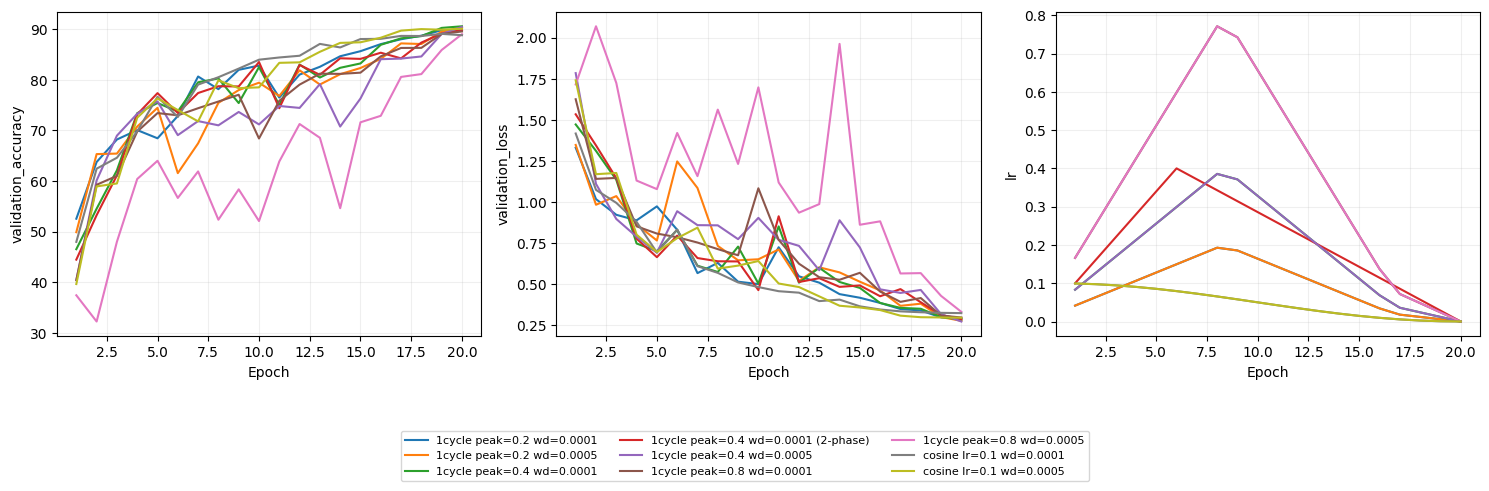

In [2]:
search = pd.read_csv("cifar_search.csv")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ["validation_accuracy", "validation_loss", "lr"]):
    for name, group in search.groupby("method"):
        axis.plot(group.epoch, group[column], label=name)
    axis.set(xlabel="Epoch", ylabel=column)
    axis.grid(alpha=0.2)
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, -0.23), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
cifar = load_data(device, dataset="cifar10")
cifar_runs = {}


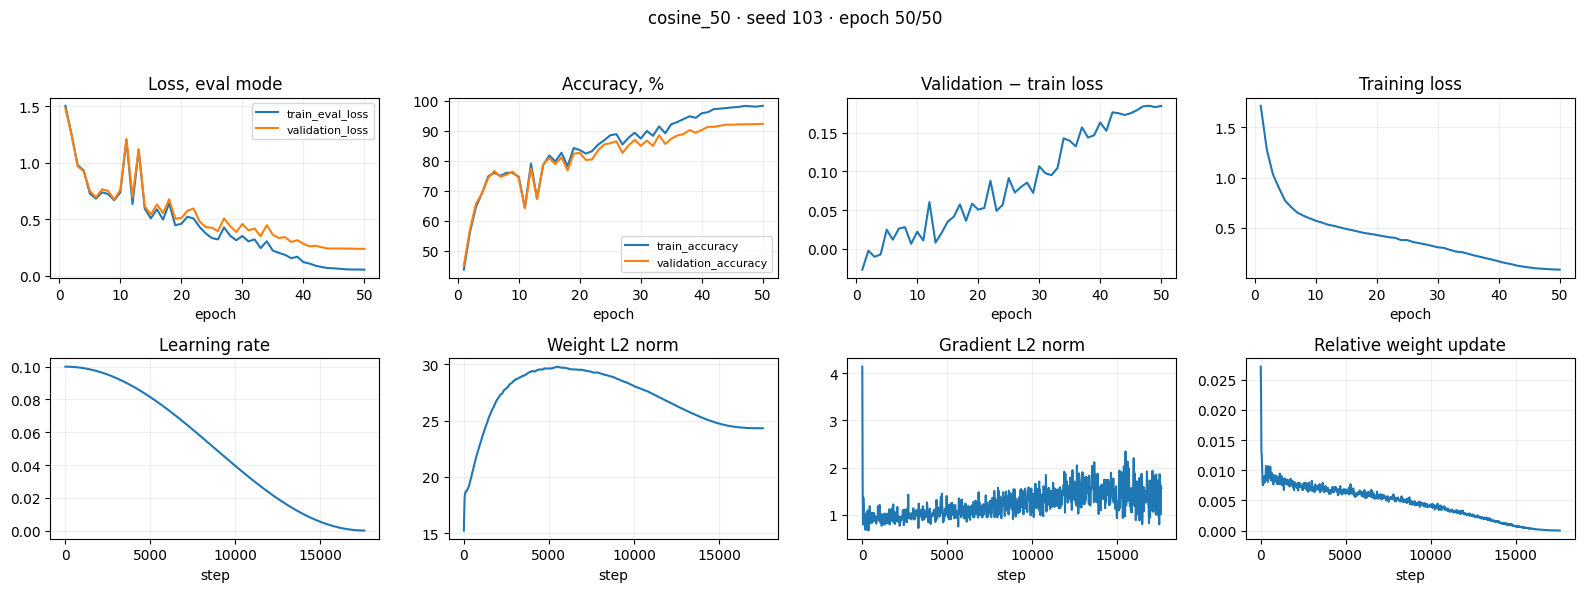

cosine_50, seed=17, epoch=1: val=46.46%, train=9.8s
cosine_50, seed=17, epoch=5: val=62.80%, train=46.3s
cosine_50, seed=17, epoch=10: val=74.22%, train=92.6s
cosine_50, seed=17, epoch=15: val=75.42%, train=138.8s
cosine_50, seed=17, epoch=20: val=80.12%, train=182.8s
cosine_50, seed=17, epoch=25: val=83.28%, train=222.1s
cosine_50, seed=17, epoch=30: val=81.94%, train=263.0s
cosine_50, seed=17, epoch=35: val=87.60%, train=299.0s
cosine_50, seed=17, epoch=40: val=90.24%, train=344.7s
cosine_50, seed=17, epoch=45: val=91.92%, train=391.2s
cosine_50, seed=17, epoch=50: val=92.16%, train=437.1s
cosine_50, seed=42, epoch=1: val=42.70%, train=9.1s
cosine_50, seed=42, epoch=5: val=72.62%, train=45.7s
cosine_50, seed=42, epoch=10: val=78.04%, train=92.1s
cosine_50, seed=42, epoch=15: val=79.46%, train=137.7s
cosine_50, seed=42, epoch=20: val=82.68%, train=175.4s
cosine_50, seed=42, epoch=25: val=86.54%, train=219.3s
cosine_50, seed=42, epoch=30: val=85.18%, train=265.8s
cosine_50, seed=42, ep

In [ ]:
name = 'cosine_50'
cifar_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(cifar, name=name, seed=seed, live=live, epochs=50, schedule='cosine', max_lr=None, lr=0.1, output="results/cifar")
    cifar_runs[name].append((history.assign(method=name, seed=seed), scores))


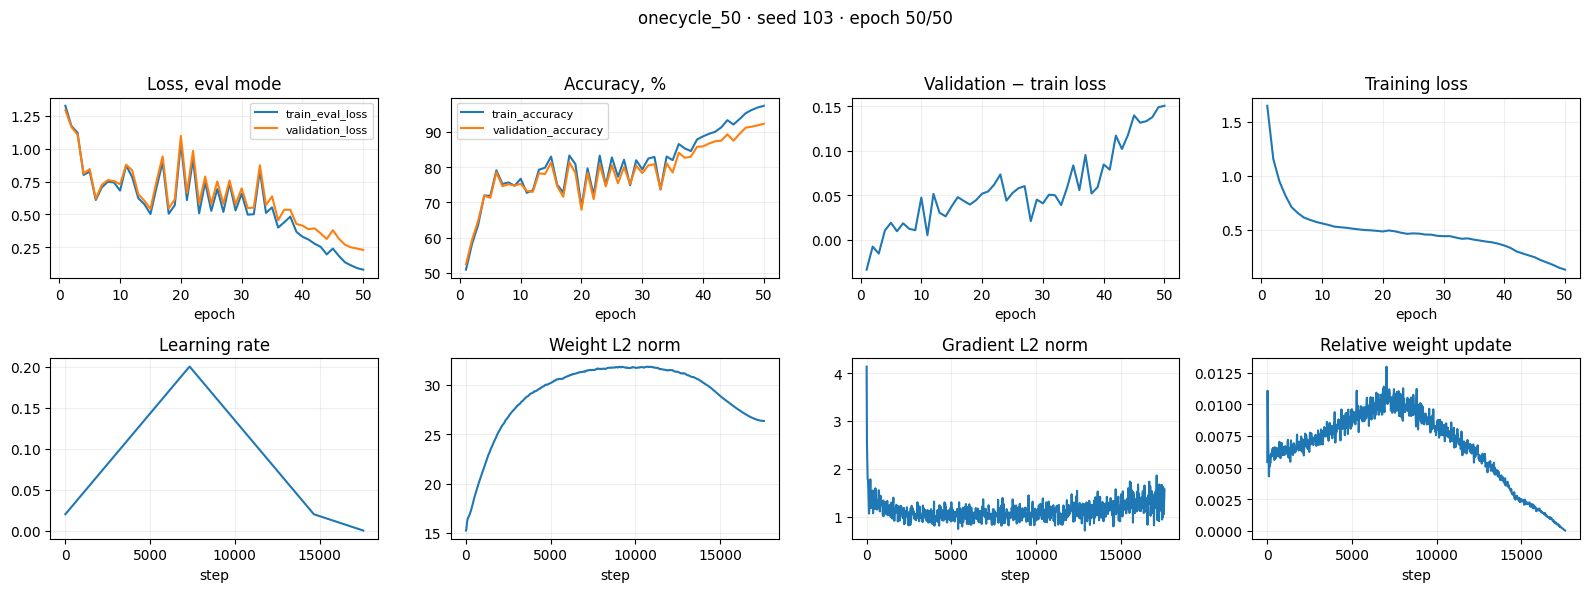

onecycle_50, seed=17, epoch=1: val=47.62%, train=9.4s
onecycle_50, seed=17, epoch=5: val=71.00%, train=46.4s
onecycle_50, seed=17, epoch=10: val=79.82%, train=95.9s
onecycle_50, seed=17, epoch=15: val=79.52%, train=141.8s
onecycle_50, seed=17, epoch=20: val=59.90%, train=187.6s
onecycle_50, seed=17, epoch=25: val=82.90%, train=234.7s
onecycle_50, seed=17, epoch=30: val=70.44%, train=281.2s
onecycle_50, seed=17, epoch=35: val=79.64%, train=326.2s
onecycle_50, seed=17, epoch=40: val=84.42%, train=372.7s
onecycle_50, seed=17, epoch=45: val=89.20%, train=417.3s
onecycle_50, seed=17, epoch=50: val=92.52%, train=463.4s
onecycle_50, seed=42, epoch=1: val=48.02%, train=9.7s
onecycle_50, seed=42, epoch=5: val=66.70%, train=47.2s
onecycle_50, seed=42, epoch=10: val=69.38%, train=93.3s
onecycle_50, seed=42, epoch=15: val=74.86%, train=138.5s
onecycle_50, seed=42, epoch=20: val=77.86%, train=186.6s
onecycle_50, seed=42, epoch=25: val=80.56%, train=234.0s
onecycle_50, seed=42, epoch=30: val=82.38%,

In [ ]:
name = 'onecycle_50'
cifar_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(cifar, name=name, seed=seed, live=live, epochs=50, schedule='onecycle', max_lr=0.2, lr=0.02, output="results/cifar")
    cifar_runs[name].append((history.assign(method=name, seed=seed), scores))


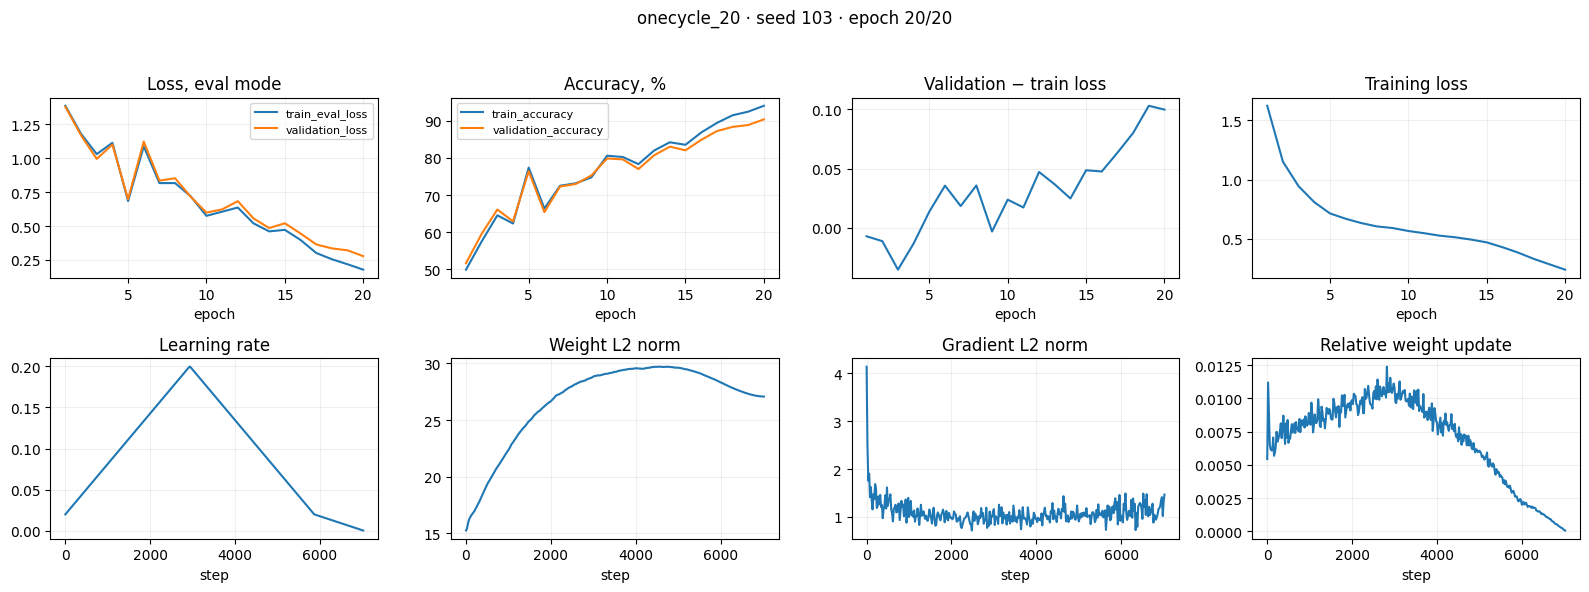

onecycle_20, seed=17, epoch=1: val=49.90%, train=9.9s
onecycle_20, seed=17, epoch=5: val=74.46%, train=49.1s
onecycle_20, seed=17, epoch=10: val=79.42%, train=95.0s
onecycle_20, seed=17, epoch=15: val=82.32%, train=144.9s
onecycle_20, seed=17, epoch=20: val=90.30%, train=193.2s
onecycle_20, seed=42, epoch=1: val=46.32%, train=9.6s
onecycle_20, seed=42, epoch=5: val=61.44%, train=46.3s
onecycle_20, seed=42, epoch=10: val=73.54%, train=90.9s
onecycle_20, seed=42, epoch=15: val=80.70%, train=136.3s
onecycle_20, seed=42, epoch=20: val=90.32%, train=185.9s
onecycle_20, seed=103, epoch=1: val=51.68%, train=9.5s
onecycle_20, seed=103, epoch=5: val=76.42%, train=47.4s
onecycle_20, seed=103, epoch=10: val=79.86%, train=94.8s
onecycle_20, seed=103, epoch=15: val=82.06%, train=142.8s
onecycle_20, seed=103, epoch=20: val=90.38%, train=191.4s


In [ ]:
name = 'onecycle_20'
cifar_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(cifar, name=name, seed=seed, live=live, epochs=20, schedule='onecycle', max_lr=0.2, lr=0.02, output="results/cifar")
    cifar_runs[name].append((history.assign(method=name, seed=seed), scores))


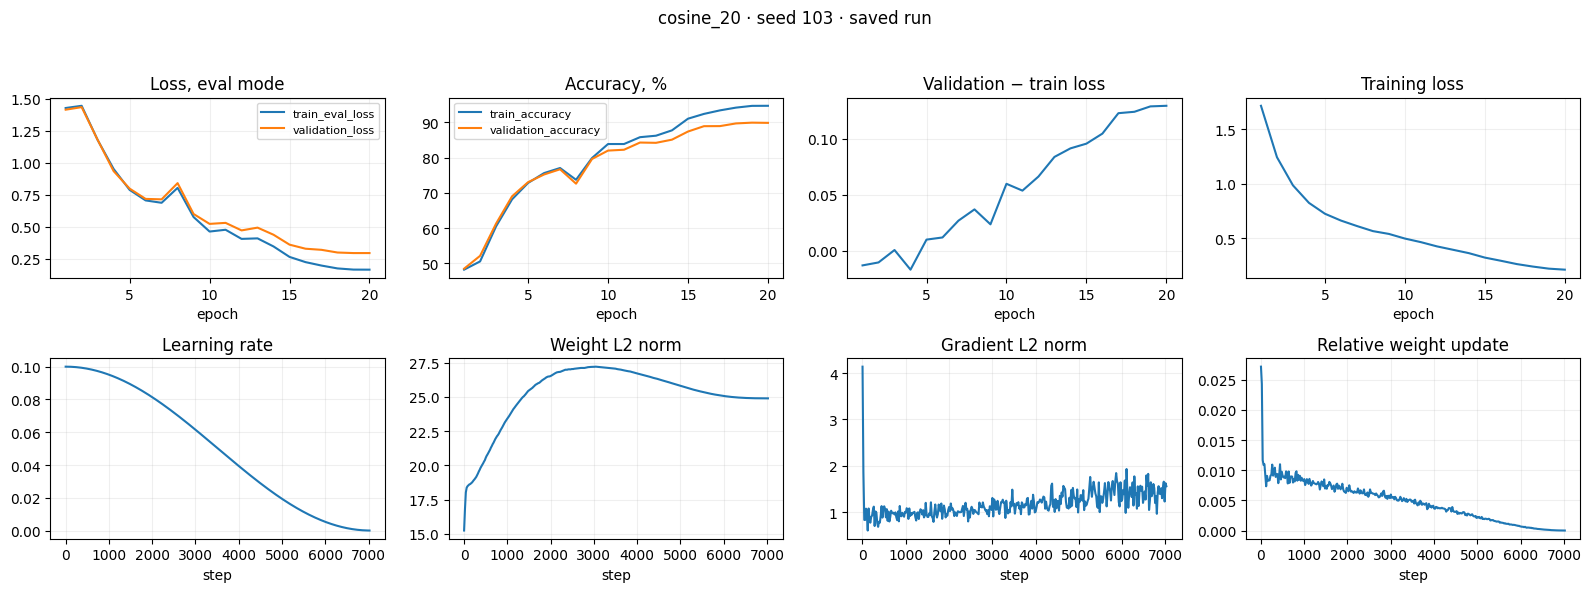

In [3]:
name = 'cosine_20'
cifar_runs[name] = []
live = LivePlot()
for seed in seeds:
    folder = Path("results/cifar") / name / str(seed)
    if (folder / "results.csv").exists():
        history = pd.read_csv(folder / "history.csv")
        scores = pd.read_csv(folder / "results.csv")
        live(history, pd.read_csv(folder / "diagnostics.csv"), f"{name} · seed {seed} · saved run")
    else:
        history, scores = train(cifar, name=name, seed=seed, live=live, epochs=20, schedule='cosine', max_lr=None, lr=0.1, weight_decay=0.0005, output="results/cifar")
    cifar_runs[name].append((history.assign(method=name, seed=seed), scores))


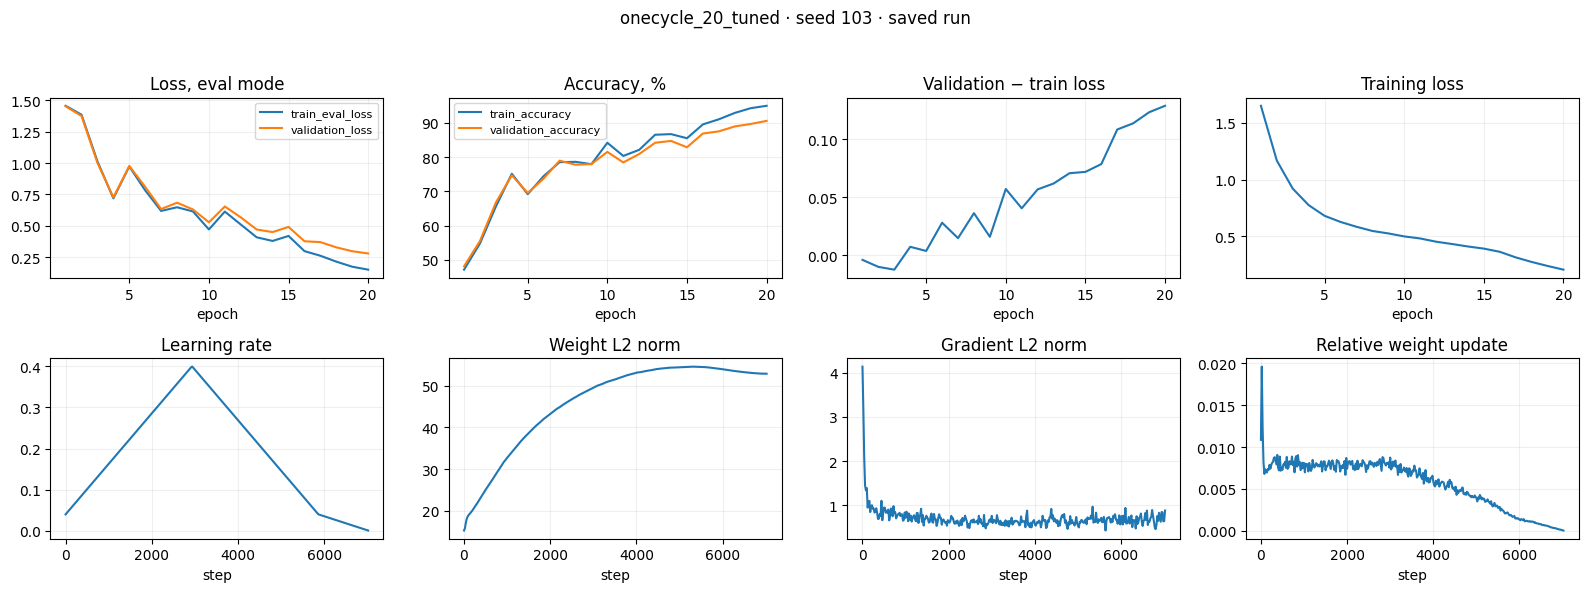

In [4]:
name = 'onecycle_20_tuned'
cifar_runs[name] = []
live = LivePlot()
for seed in seeds:
    folder = Path("results/cifar") / name / str(seed)
    if (folder / "results.csv").exists():
        history = pd.read_csv(folder / "history.csv")
        scores = pd.read_csv(folder / "results.csv")
        live(history, pd.read_csv(folder / "diagnostics.csv"), f"{name} · seed {seed} · saved run")
    else:
        history, scores = train(cifar, name=name, seed=seed, live=live, epochs=20, max_lr=0.4, lr=0.04, weight_decay=0.0001, output="results/cifar")
    cifar_runs[name].append((history.assign(method=name, seed=seed), scores))


In [5]:
cifar_history = pd.concat([h for runs in cifar_runs.values() for h, _ in runs], ignore_index=True)
cifar_results = pd.concat([s for runs in cifar_runs.values() for _, s in runs], ignore_index=True)


In [6]:
cifar_results.groupby("method").agg(accuracy=("test_accuracy", "mean"), std=("test_accuracy", "std"), seconds=("train_seconds", "mean"))


,accuracy,std,seconds
method,,,
cosine_20,89.323333,0.096090,183.980934
cosine_50,91.513333,0.127410,450.445016
onecycle_20,89.806667,0.153731,190.146030
onecycle_20_tuned,89.576667,0.272274,145.060657
onecycle_50,91.576667,0.262742,469.604054


### Сравнение результатов

| Режим | Эпохи | Validation accuracy, % | Test accuracy, % |
| --- | --- | --- | --- |
| Cosine, выбранный | 20 | 89,907 ± 0,151 | 89,323 ± 0,096 |
| 1cycle, исходный | 20 | 90,333 ± 0,042 | 89,807 ± 0,154 |
| 1cycle, выбранный | 20 | 90,720 ± 0,277 | 89,577 ± 0,272 |
| Cosine, длинный | 50 | 92,080 ± 0,269 | 91,513 ± 0,127 |
| 1cycle, длинный | 50 | 92,413 ± 0,092 | 91,577 ± 0,263 |

При одинаковых 20 эпохах выбранный 1cycle выше cosine на **0,253 п.п.** test accuracy; выигрыш есть на двух seed из трех. Исходный 1cycle тоже выше cosine — на **0,483 п.п.** Главное исправление опыта — сравнение с cosine, рассчитанным на те же 20 эпох.

Подбор повысил среднюю validation accuracy с 90,333% до 90,720%, но **не улучшил test** относительно исходного 1cycle: 89,577% против 89,807%. Выбирать новую конфигурацию только потому, что она лучше на одном validation seed, оказалось недостаточно. Оставляем оба результата, не объявляя подобранный вариант лучшим по test.

Длинные запуски дают около 91,5%: за 20 эпох это качество пока не достигнуто. То есть преимущество 1cycle при равном коротком бюджете видно, а сильное сокращение обучения без потери качества, как на MNIST, здесь не воспроизведено. Время новых запусков зависело от параллельной нагрузки; для этого сравнения фиксируем число эпох.

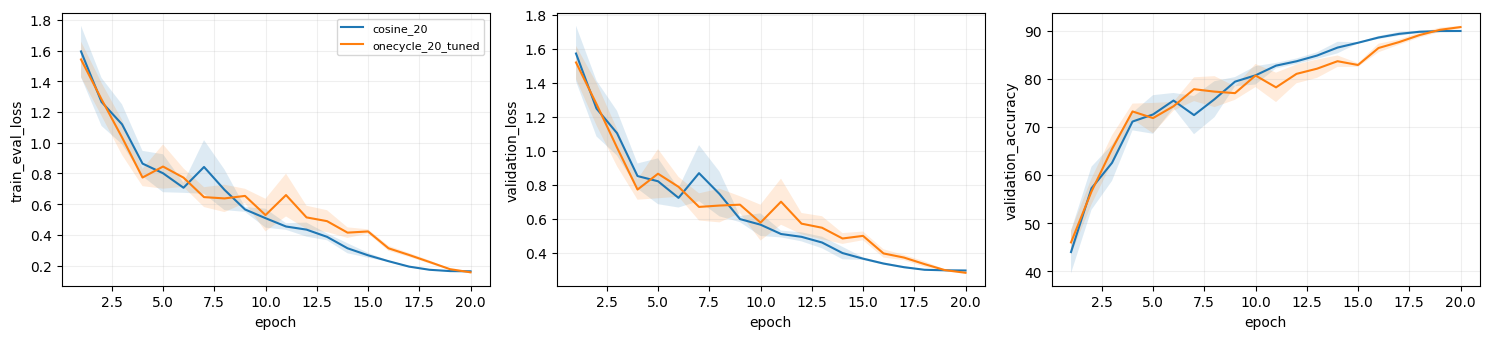

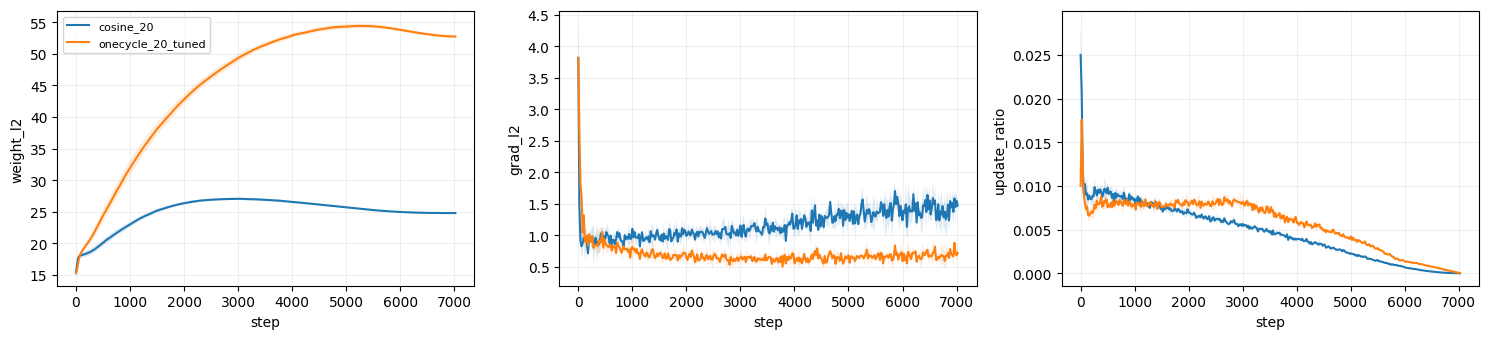

In [7]:
best = ["cosine_20", "onecycle_20_tuned"]
plot_curves(cifar_history[cifar_history.method.isin(best)], "epoch", ["train_eval_loss", "validation_loss", "validation_accuracy"])
cifar_norms = read_diagnostics("results/cifar")
plot_curves(cifar_norms[cifar_norms.method.isin(best)], "step", ["weight_l2", "grad_l2", "update_ratio"])


### Loss и нормы выбранных моделей

| Режим | Train loss | Validation loss | Gap | Норма весов |
| --- | --- | --- | --- | --- |
| Cosine, выбранный | 0,1630 | 0,2951 | 0,1321 | 24,774 |
| 1cycle, выбранный | 0,1564 | 0,2817 | 0,1252 | 52,766 |

Снижение loss к концу короткого цикла — повод проверить больший бюджет, но само по себе не доказывает несходимость. Запуски на 50 эпохах действительно дают более высокую accuracy. Нормы используем как диагностику процесса обучения, а не как критерий выбора победителя.

## Часть 3. Регуляризующий эффект

**Что делаем:** на 10 000 train-примерах MNIST сравниваем два пика LR и три значения weight decay. Длительность — 40 эпох, momentum фиксирован на 0,9.

**Гипотеза:** большой LR частично заменяет явную регуляризацию. Если это так, ожидаем меньший train–validation gap и меньшую потребность в weight decay. Проверяем одновременно качество и нормы весов: одной маленькой нормы недостаточно.

In [ ]:
reg_data = load_data(device, train_size=10000)
reg_runs = {}


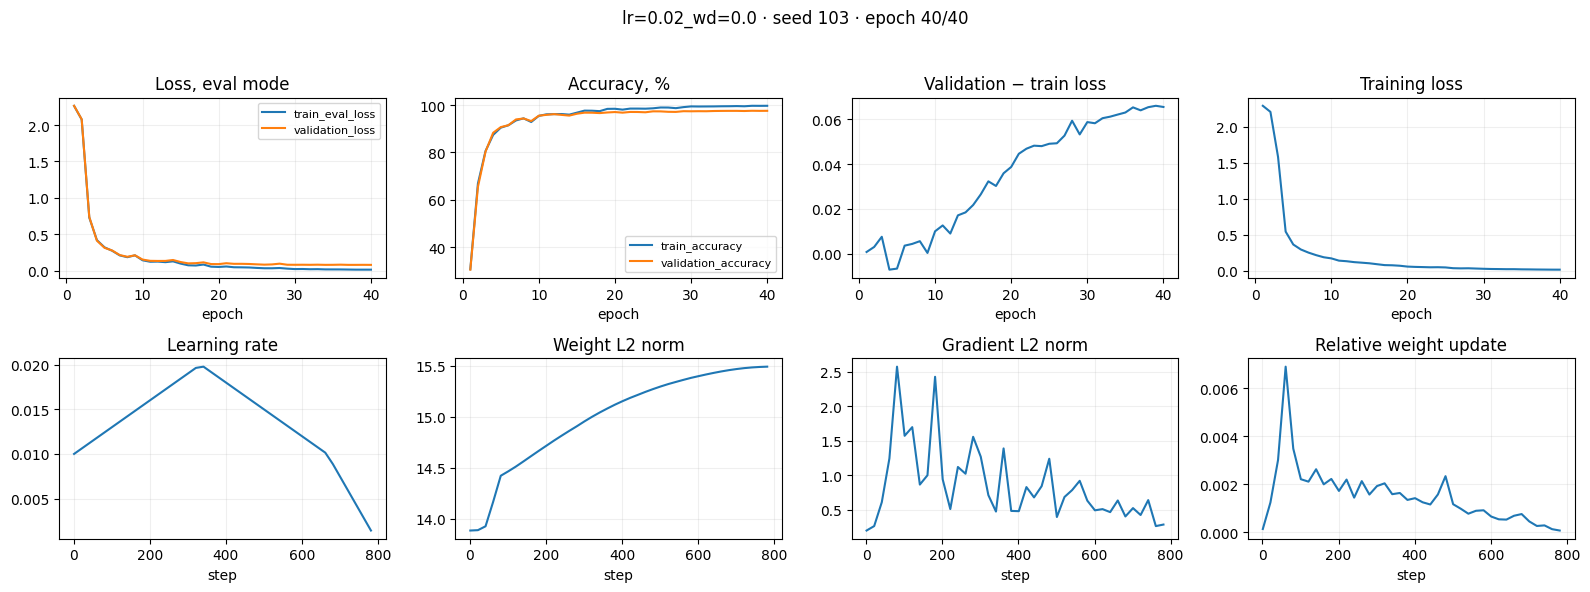

lr=0.02_wd=0.0, seed=17, epoch=1: val=45.36%, train=0.1s
lr=0.02_wd=0.0, seed=17, epoch=5: val=90.60%, train=0.7s
lr=0.02_wd=0.0, seed=17, epoch=10: val=95.88%, train=1.2s
lr=0.02_wd=0.0, seed=17, epoch=15: val=96.76%, train=2.0s
lr=0.02_wd=0.0, seed=17, epoch=20: val=97.36%, train=2.7s
lr=0.02_wd=0.0, seed=17, epoch=25: val=97.24%, train=3.4s
lr=0.02_wd=0.0, seed=17, epoch=30: val=97.70%, train=4.1s
lr=0.02_wd=0.0, seed=17, epoch=35: val=97.66%, train=4.6s
lr=0.02_wd=0.0, seed=17, epoch=40: val=97.76%, train=5.1s
lr=0.02_wd=0.0, seed=42, epoch=1: val=25.86%, train=0.1s
lr=0.02_wd=0.0, seed=42, epoch=5: val=87.84%, train=0.5s
lr=0.02_wd=0.0, seed=42, epoch=10: val=95.26%, train=1.0s
lr=0.02_wd=0.0, seed=42, epoch=15: val=96.30%, train=1.8s
lr=0.02_wd=0.0, seed=42, epoch=20: val=97.18%, train=2.5s
lr=0.02_wd=0.0, seed=42, epoch=25: val=97.46%, train=3.2s
lr=0.02_wd=0.0, seed=42, epoch=30: val=97.50%, train=4.0s
lr=0.02_wd=0.0, seed=42, epoch=35: val=97.32%, train=4.5s
lr=0.02_wd=0.0, se

In [ ]:
name = 'lr=0.02_wd=0.0'
reg_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(reg_data, name=name, seed=seed, live=live, epochs=40, max_lr=0.02, weight_decay=0.0, cycle_momentum=False, output="results/regularization")
    reg_runs[name].append((history.assign(method=name, seed=seed, peak=0.02, weight_decay=0.0), scores.assign(peak=0.02, weight_decay=0.0)))


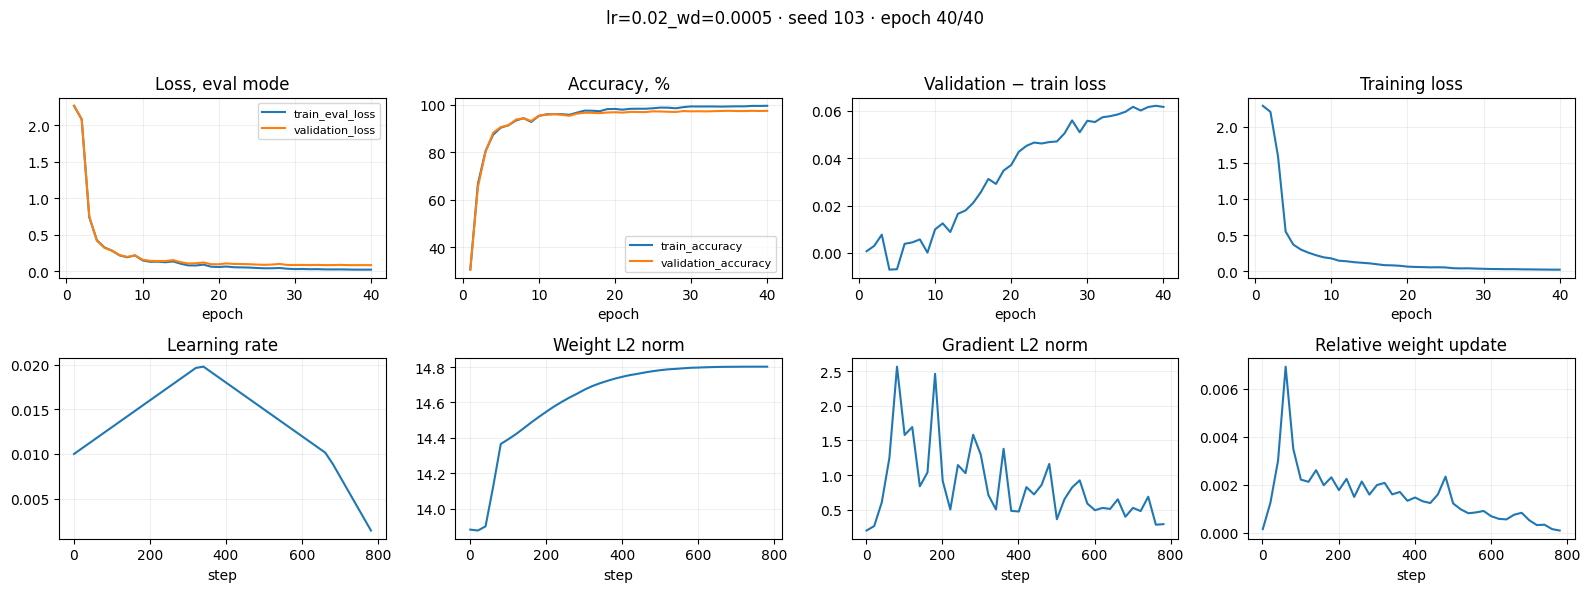

lr=0.02_wd=0.0005, seed=17, epoch=1: val=45.34%, train=0.1s
lr=0.02_wd=0.0005, seed=17, epoch=5: val=90.62%, train=0.7s
lr=0.02_wd=0.0005, seed=17, epoch=10: val=95.84%, train=1.4s
lr=0.02_wd=0.0005, seed=17, epoch=15: val=96.82%, train=2.2s
lr=0.02_wd=0.0005, seed=17, epoch=20: val=97.30%, train=2.9s
lr=0.02_wd=0.0005, seed=17, epoch=25: val=97.22%, train=3.5s
lr=0.02_wd=0.0005, seed=17, epoch=30: val=97.70%, train=4.1s
lr=0.02_wd=0.0005, seed=17, epoch=35: val=97.66%, train=4.8s
lr=0.02_wd=0.0005, seed=17, epoch=40: val=97.78%, train=5.5s
lr=0.02_wd=0.0005, seed=42, epoch=1: val=25.80%, train=0.1s
lr=0.02_wd=0.0005, seed=42, epoch=5: val=87.88%, train=0.7s
lr=0.02_wd=0.0005, seed=42, epoch=10: val=95.26%, train=1.4s
lr=0.02_wd=0.0005, seed=42, epoch=15: val=96.34%, train=2.0s
lr=0.02_wd=0.0005, seed=42, epoch=20: val=97.08%, train=2.4s
lr=0.02_wd=0.0005, seed=42, epoch=25: val=97.40%, train=2.9s
lr=0.02_wd=0.0005, seed=42, epoch=30: val=97.64%, train=3.4s
lr=0.02_wd=0.0005, seed=42, 

In [ ]:
name = 'lr=0.02_wd=0.0005'
reg_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(reg_data, name=name, seed=seed, live=live, epochs=40, max_lr=0.02, weight_decay=0.0005, cycle_momentum=False, output="results/regularization")
    reg_runs[name].append((history.assign(method=name, seed=seed, peak=0.02, weight_decay=0.0005), scores.assign(peak=0.02, weight_decay=0.0005)))


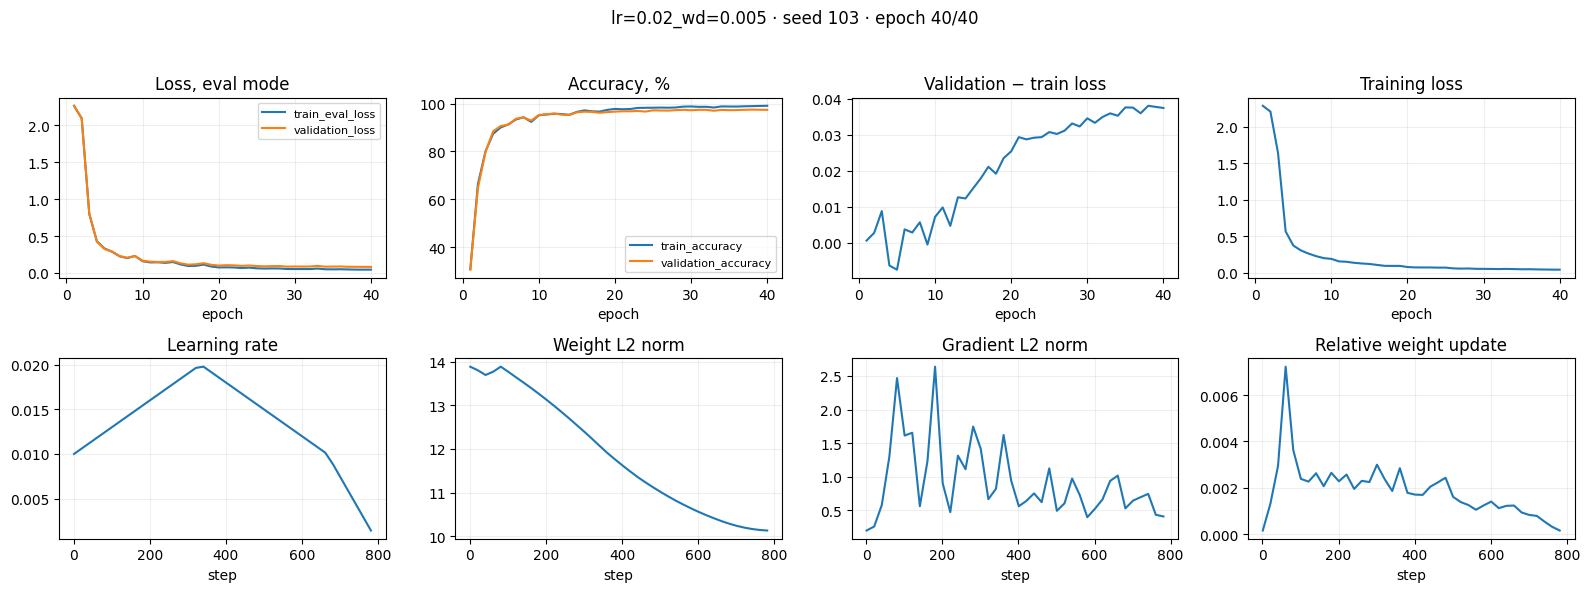

lr=0.02_wd=0.005, seed=17, epoch=1: val=44.96%, train=0.1s
lr=0.02_wd=0.005, seed=17, epoch=5: val=90.50%, train=0.7s
lr=0.02_wd=0.005, seed=17, epoch=10: val=95.60%, train=1.2s
lr=0.02_wd=0.005, seed=17, epoch=15: val=96.68%, train=1.7s
lr=0.02_wd=0.005, seed=17, epoch=20: val=97.14%, train=2.2s
lr=0.02_wd=0.005, seed=17, epoch=25: val=97.38%, train=2.9s
lr=0.02_wd=0.005, seed=17, epoch=30: val=97.52%, train=3.5s
lr=0.02_wd=0.005, seed=17, epoch=35: val=97.52%, train=4.1s
lr=0.02_wd=0.005, seed=17, epoch=40: val=97.68%, train=4.8s
lr=0.02_wd=0.005, seed=42, epoch=1: val=25.46%, train=0.1s
lr=0.02_wd=0.005, seed=42, epoch=5: val=87.88%, train=0.7s
lr=0.02_wd=0.005, seed=42, epoch=10: val=94.96%, train=1.1s
lr=0.02_wd=0.005, seed=42, epoch=15: val=96.22%, train=1.6s
lr=0.02_wd=0.005, seed=42, epoch=20: val=96.84%, train=2.3s
lr=0.02_wd=0.005, seed=42, epoch=25: val=97.32%, train=2.7s
lr=0.02_wd=0.005, seed=42, epoch=30: val=97.26%, train=3.4s
lr=0.02_wd=0.005, seed=42, epoch=35: val=97.

In [ ]:
name = 'lr=0.02_wd=0.005'
reg_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(reg_data, name=name, seed=seed, live=live, epochs=40, max_lr=0.02, weight_decay=0.005, cycle_momentum=False, output="results/regularization")
    reg_runs[name].append((history.assign(method=name, seed=seed, peak=0.02, weight_decay=0.005), scores.assign(peak=0.02, weight_decay=0.005)))


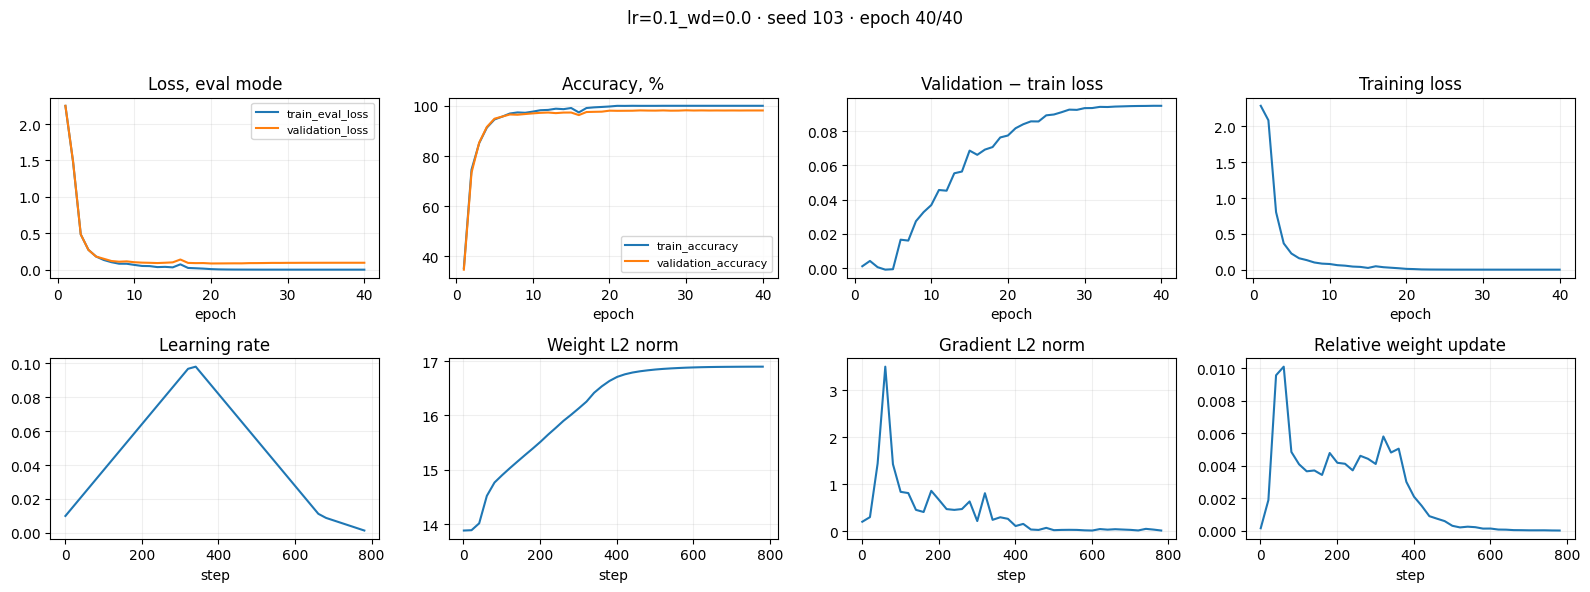

lr=0.1_wd=0.0, seed=17, epoch=1: val=52.40%, train=0.1s
lr=0.1_wd=0.0, seed=17, epoch=5: val=94.68%, train=0.7s
lr=0.1_wd=0.0, seed=17, epoch=10: val=96.98%, train=1.2s
lr=0.1_wd=0.0, seed=17, epoch=15: val=97.26%, train=1.9s
lr=0.1_wd=0.0, seed=17, epoch=20: val=97.86%, train=2.4s
lr=0.1_wd=0.0, seed=17, epoch=25: val=98.06%, train=2.9s
lr=0.1_wd=0.0, seed=17, epoch=30: val=98.06%, train=3.6s
lr=0.1_wd=0.0, seed=17, epoch=35: val=98.08%, train=4.2s
lr=0.1_wd=0.0, seed=17, epoch=40: val=98.10%, train=4.6s
lr=0.1_wd=0.0, seed=42, epoch=1: val=32.70%, train=0.1s
lr=0.1_wd=0.0, seed=42, epoch=5: val=94.44%, train=0.6s
lr=0.1_wd=0.0, seed=42, epoch=10: val=96.72%, train=1.1s
lr=0.1_wd=0.0, seed=42, epoch=15: val=97.62%, train=1.8s
lr=0.1_wd=0.0, seed=42, epoch=20: val=98.08%, train=2.3s
lr=0.1_wd=0.0, seed=42, epoch=25: val=98.26%, train=2.8s
lr=0.1_wd=0.0, seed=42, epoch=30: val=98.24%, train=3.5s
lr=0.1_wd=0.0, seed=42, epoch=35: val=98.30%, train=4.1s
lr=0.1_wd=0.0, seed=42, epoch=40: v

In [ ]:
name = 'lr=0.1_wd=0.0'
reg_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(reg_data, name=name, seed=seed, live=live, epochs=40, max_lr=0.1, weight_decay=0.0, cycle_momentum=False, output="results/regularization")
    reg_runs[name].append((history.assign(method=name, seed=seed, peak=0.1, weight_decay=0.0), scores.assign(peak=0.1, weight_decay=0.0)))


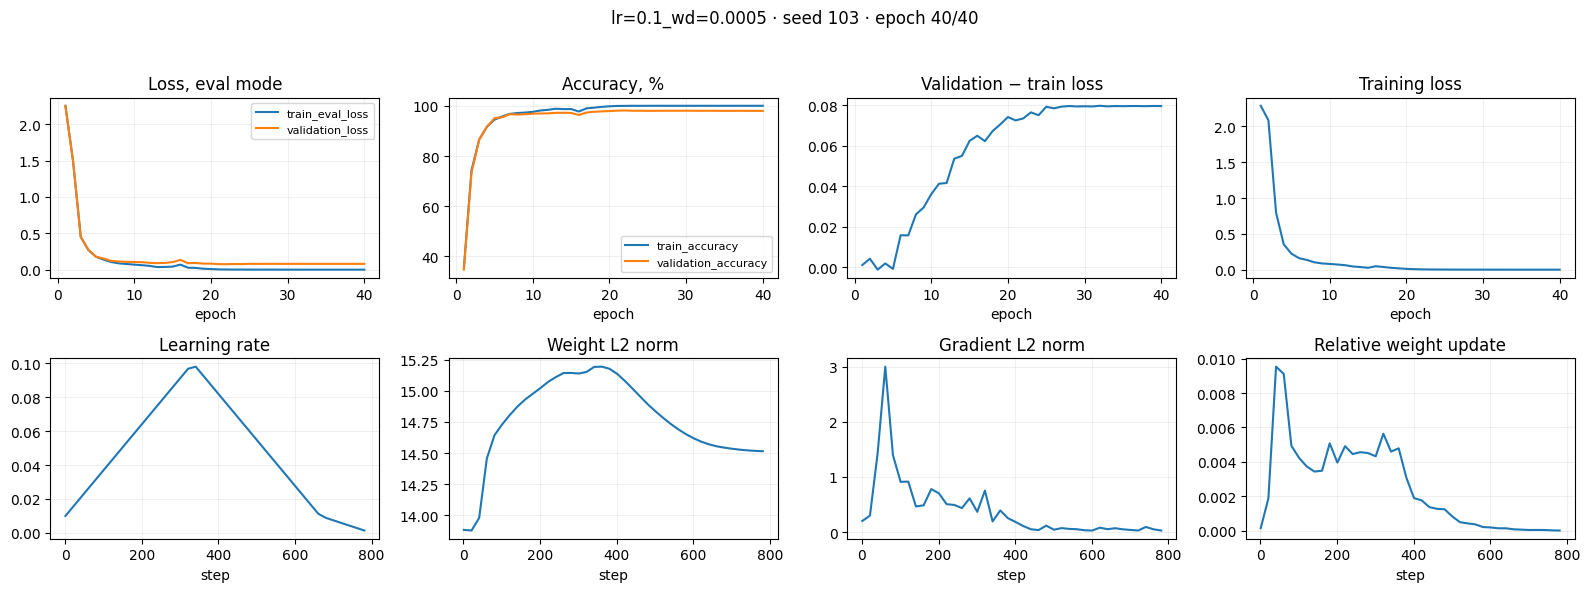

lr=0.1_wd=0.0005, seed=17, epoch=1: val=52.32%, train=0.1s
lr=0.1_wd=0.0005, seed=17, epoch=5: val=94.66%, train=0.5s
lr=0.1_wd=0.0005, seed=17, epoch=10: val=96.88%, train=1.0s
lr=0.1_wd=0.0005, seed=17, epoch=15: val=97.12%, train=1.7s
lr=0.1_wd=0.0005, seed=17, epoch=20: val=97.94%, train=2.3s
lr=0.1_wd=0.0005, seed=17, epoch=25: val=98.12%, train=2.9s
lr=0.1_wd=0.0005, seed=17, epoch=30: val=98.14%, train=3.4s
lr=0.1_wd=0.0005, seed=17, epoch=35: val=98.14%, train=3.9s
lr=0.1_wd=0.0005, seed=17, epoch=40: val=98.14%, train=4.6s
lr=0.1_wd=0.0005, seed=42, epoch=1: val=32.66%, train=0.1s
lr=0.1_wd=0.0005, seed=42, epoch=5: val=94.52%, train=0.6s
lr=0.1_wd=0.0005, seed=42, epoch=10: val=96.80%, train=1.2s
lr=0.1_wd=0.0005, seed=42, epoch=15: val=97.62%, train=1.9s
lr=0.1_wd=0.0005, seed=42, epoch=20: val=98.28%, train=2.4s
lr=0.1_wd=0.0005, seed=42, epoch=25: val=98.14%, train=2.9s
lr=0.1_wd=0.0005, seed=42, epoch=30: val=98.24%, train=3.5s
lr=0.1_wd=0.0005, seed=42, epoch=35: val=98.

In [ ]:
name = 'lr=0.1_wd=0.0005'
reg_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(reg_data, name=name, seed=seed, live=live, epochs=40, max_lr=0.1, weight_decay=0.0005, cycle_momentum=False, output="results/regularization")
    reg_runs[name].append((history.assign(method=name, seed=seed, peak=0.1, weight_decay=0.0005), scores.assign(peak=0.1, weight_decay=0.0005)))


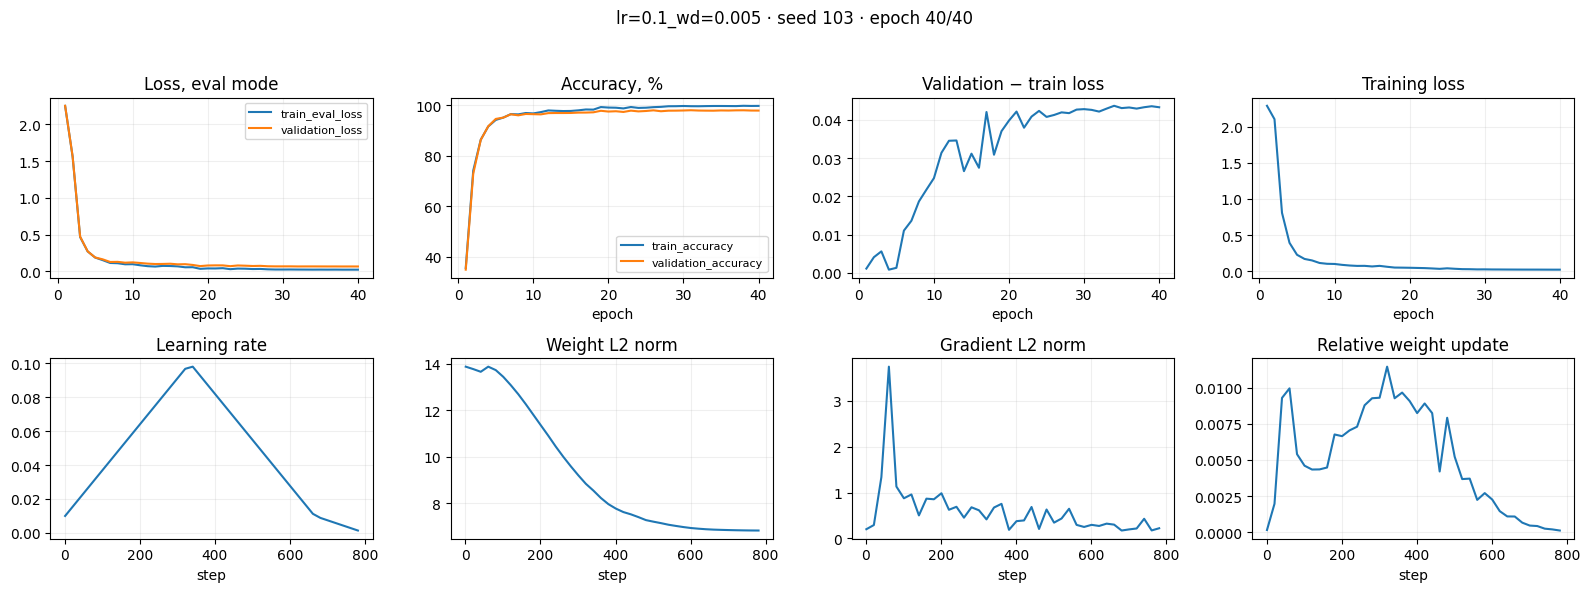

lr=0.1_wd=0.005, seed=17, epoch=1: val=52.20%, train=0.1s
lr=0.1_wd=0.005, seed=17, epoch=5: val=94.58%, train=0.6s
lr=0.1_wd=0.005, seed=17, epoch=10: val=96.88%, train=1.0s
lr=0.1_wd=0.005, seed=17, epoch=15: val=97.12%, train=1.7s
lr=0.1_wd=0.005, seed=17, epoch=20: val=97.64%, train=2.3s
lr=0.1_wd=0.005, seed=17, epoch=25: val=97.82%, train=2.9s
lr=0.1_wd=0.005, seed=17, epoch=30: val=97.92%, train=3.5s
lr=0.1_wd=0.005, seed=17, epoch=35: val=98.00%, train=4.3s
lr=0.1_wd=0.005, seed=17, epoch=40: val=98.02%, train=4.8s
lr=0.1_wd=0.005, seed=42, epoch=1: val=32.26%, train=0.1s
lr=0.1_wd=0.005, seed=42, epoch=5: val=94.14%, train=0.5s
lr=0.1_wd=0.005, seed=42, epoch=10: val=96.68%, train=1.1s
lr=0.1_wd=0.005, seed=42, epoch=15: val=96.86%, train=1.7s
lr=0.1_wd=0.005, seed=42, epoch=20: val=97.66%, train=2.4s
lr=0.1_wd=0.005, seed=42, epoch=25: val=97.98%, train=3.0s
lr=0.1_wd=0.005, seed=42, epoch=30: val=97.96%, train=3.5s
lr=0.1_wd=0.005, seed=42, epoch=35: val=97.84%, train=4.1s
l

In [ ]:
name = 'lr=0.1_wd=0.005'
reg_runs[name] = []
live = LivePlot()
for seed in seeds:
    history, scores = train(reg_data, name=name, seed=seed, live=live, epochs=40, max_lr=0.1, weight_decay=0.005, cycle_momentum=False, output="results/regularization")
    reg_runs[name].append((history.assign(method=name, seed=seed, peak=0.1, weight_decay=0.005), scores.assign(peak=0.1, weight_decay=0.005)))


In [ ]:
reg_history = pd.concat([h for runs in reg_runs.values() for h, _ in runs], ignore_index=True)
reg_results = pd.concat([s for runs in reg_runs.values() for _, s in runs], ignore_index=True)


train_eval_loss  validation_loss       gap  \
peak weight_decay                                               
0.02 0.0000               0.017183         0.081720  0.064536   
     0.0005               0.019488         0.080113  0.060625   
     0.0050               0.043058         0.080682  0.037623   
0.10 0.0000               0.000736         0.092737  0.092001   
     0.0005               0.001861         0.077735  0.075873   
     0.0050               0.024039         0.066951  0.042912   

                   validation_accuracy  
peak weight_decay                       
0.02 0.0000                  97.666667  
     0.0005                  97.666667  
     0.0050                  97.566667  
0.10 0.0000                  98.180000  
     0.0005                  98.093333  
     0.0050                  97.933333

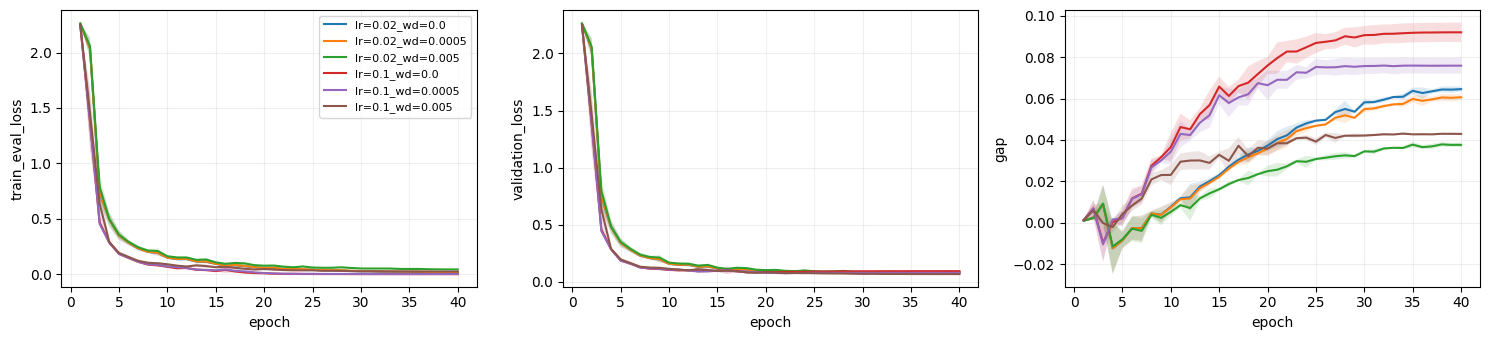

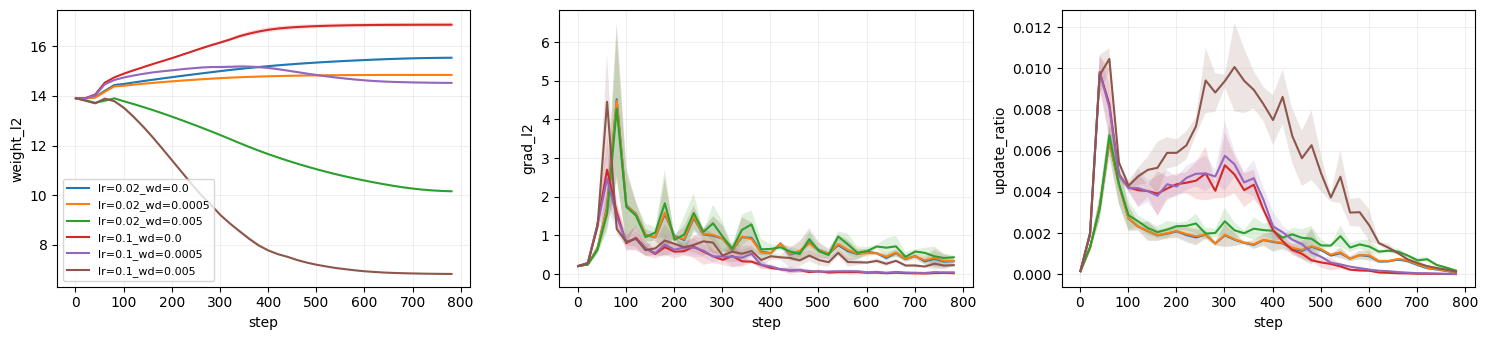

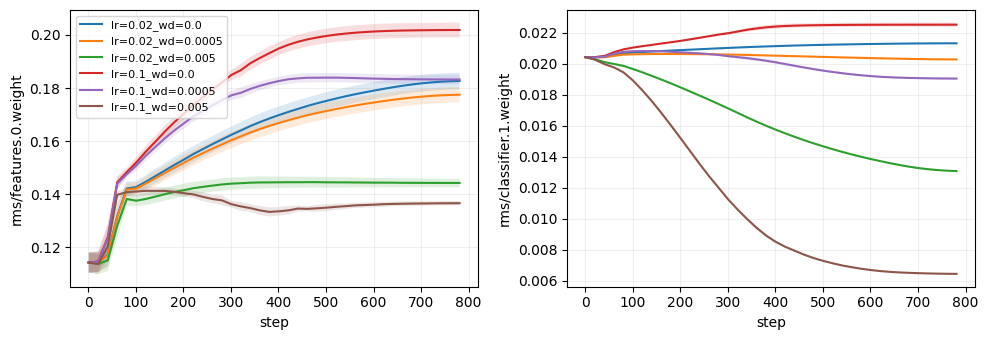

In [ ]:
last_epoch = reg_history.loc[reg_history.epoch == 40]
display(last_epoch.groupby(["peak", "weight_decay"])[["train_eval_loss", "validation_loss", "gap", "validation_accuracy"]].mean())
plot_curves(reg_history, "epoch", ["train_eval_loss", "validation_loss", "gap"])
reg_norms = read_diagnostics("results/regularization")
plot_curves(reg_norms, "step", ["weight_l2", "grad_l2", "update_ratio"])
plot_curves(reg_norms, "step", ["rms/features.0.weight", "rms/classifier.1.weight"])

### Результат

| Пик LR | Weight decay | Validation loss | Gap | Норма весов | Test accuracy, % |
| --- | --- | --- | --- | --- | --- |
| 0,02 | 0,0000 | 0,0817 | 0,0645 | 15,532 | 98,023 ± 0,090 |
| 0,02 | 0,0005 | 0,0801 | 0,0606 | 14,841 | 97,987 ± 0,093 |
| 0,02 | 0,0050 | 0,0807 | 0,0376 | 10,159 | 97,917 ± 0,023 |
| 0,10 | 0,0000 | 0,0927 | 0,0920 | 16,862 | 98,420 ± 0,036 |
| 0,10 | 0,0005 | 0,0777 | 0,0759 | 14,521 | 98,467 ± 0,097 |
| 0,10 | 0,0050 | 0,0670 | 0,0429 | 6,832 | 98,277 ± 0,012 |

Без decay увеличение пика повышает точность, но также увеличивает gap (0,0645 → 0,0920) и норму весов (15,532 → 16,862). Поэтому **большой LR не оказался заменой L2-регуляризации**.

При пике 0,1 добавление decay=0,005 снижает validation loss с 0,0927 до 0,0670. Лучший test accuracy — 98,467% при decay=0,0005. LR и decay взаимодействуют; оптимальная настройка зависит и от метрики. В SGD само действие decay масштабируется learning rate, поэтому эти два фактора нельзя считать независимыми.

## Часть 4. Перенос на RL

**Что делаем:** обучаем DQN из [Stable-Baselines3](https://stable-baselines3.readthedocs.io/en/v2.7.0/modules/dqn.html) в LunarLander-v3 с constant, cosine и 1cycle. Сеть 256–256, Adam, по 100 000 шагов среды. Базовый LR=0,00063, пик 1cycle=0,00189; остальные настройки одинаковы.

**Гипотеза:** 1cycle ускорит обучение и здесь. Ожидаем более раннего роста награды и лучшего финального агента при том же бюджете.

Eval — 10 фиксированных эпизодов, test — другие 50. Оцениваем финальные веса. Видео на отдельном seed служит иллюстрацией, а не основной метрикой.

In [ ]:
from rl import train_rl

rl_runs = {}


step=0: reward=-338.1 ± 128.6


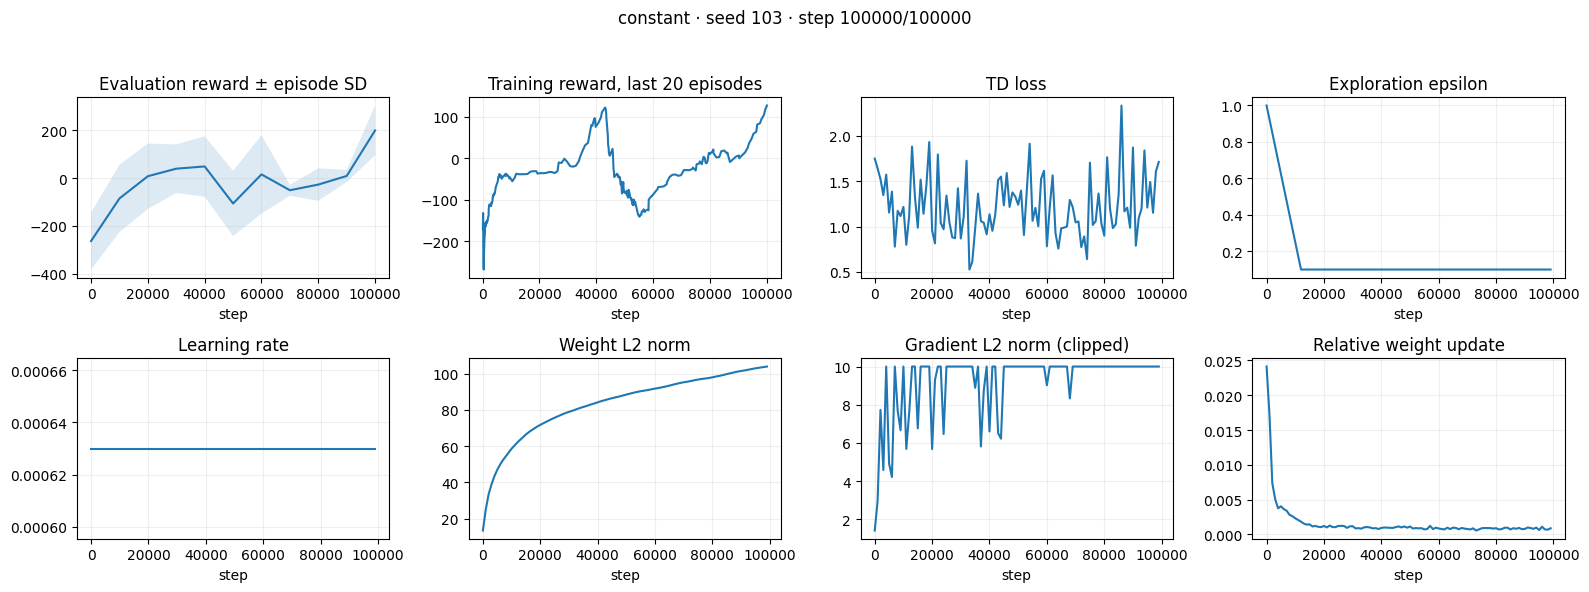

step=10000: reward=-98.1 ± 79.9
step=20000: reward=-20.3 ± 32.1
step=30000: reward=173.1 ± 125.4
step=40000: reward=124.7 ± 101.6
step=50000: reward=64.1 ± 153.7
step=60000: reward=170.9 ± 182.7
step=70000: reward=160.6 ± 104.3
step=80000: reward=177.0 ± 126.6
step=90000: reward=36.2 ± 38.6
step=100000: reward=180.0 ± 70.1
step=0: reward=-565.0 ± 154.9
step=10000: reward=-92.5 ± 83.0
step=20000: reward=-27.0 ± 17.4
step=30000: reward=42.0 ± 94.4
step=40000: reward=152.2 ± 91.6
step=50000: reward=198.7 ± 102.0
step=60000: reward=156.4 ± 127.6
step=70000: reward=95.5 ± 73.7
step=80000: reward=114.8 ± 73.4
step=90000: reward=147.5 ± 60.3
step=100000: reward=236.2 ± 43.9
step=0: reward=-263.4 ± 118.9
step=10000: reward=-85.4 ± 141.0
step=20000: reward=7.5 ± 136.5
step=30000: reward=39.0 ± 101.5
step=40000: reward=48.3 ± 126.4
step=50000: reward=-106.5 ± 136.3
step=60000: reward=15.2 ± 164.0
step=70000: reward=-51.1 ± 22.8
step=80000: reward=-27.5 ± 67.9
step=90000: reward=8.5 ± 25.5
step=1

In [ ]:
kind = 'constant'
rl_runs[kind] = []
live = LivePlot(rl=True)
for seed in seeds:
    history, result = train_rl(kind, seed, steps=100000, live=live, live_every=2000, video_every=25000)
    rl_runs[kind].append((history.assign(method=kind, seed=seed), result))


step=0: reward=-338.1 ± 128.6


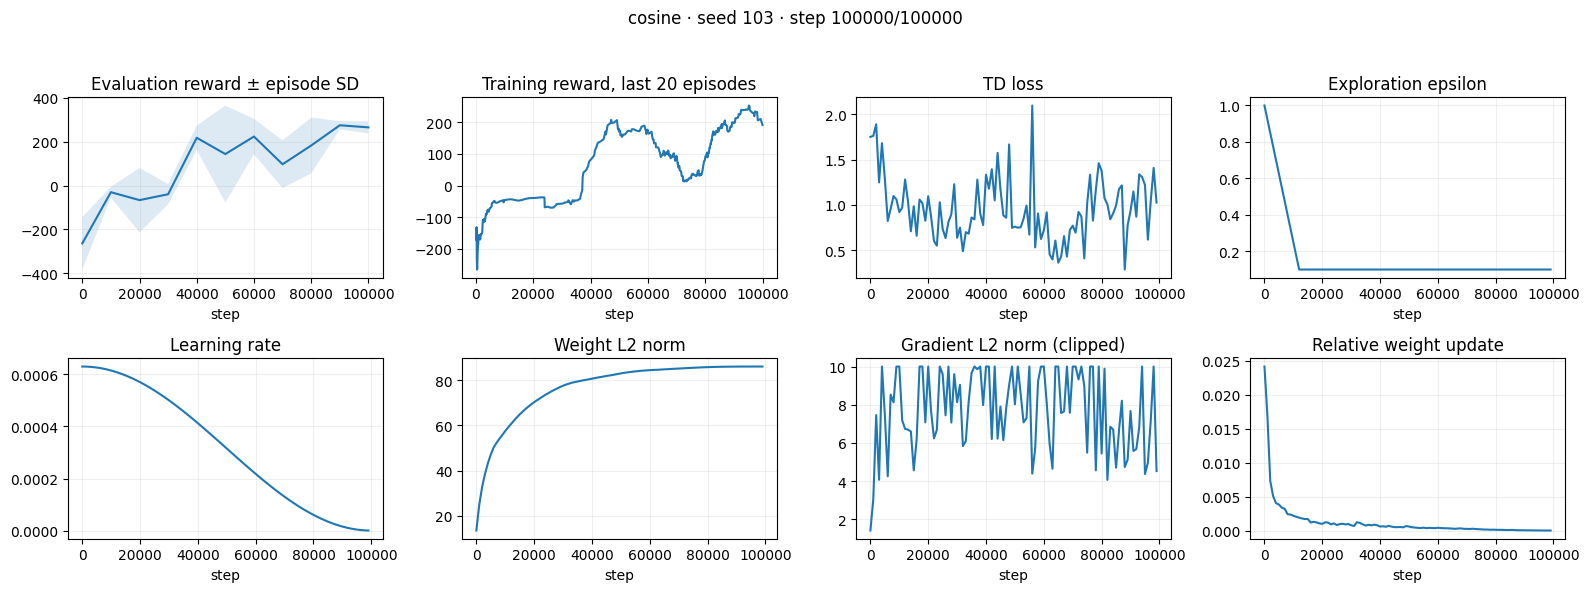

step=10000: reward=-144.9 ± 29.0
step=20000: reward=49.4 ± 194.6
step=30000: reward=233.4 ± 52.5
step=40000: reward=244.9 ± 52.8
step=50000: reward=163.5 ± 147.5
step=60000: reward=171.4 ± 142.6
step=70000: reward=247.1 ± 38.0
step=80000: reward=209.0 ± 108.7
step=90000: reward=222.3 ± 41.2
step=100000: reward=237.3 ± 57.7
step=0: reward=-565.0 ± 154.9
step=10000: reward=-148.5 ± 20.1
step=20000: reward=187.8 ± 66.2
step=30000: reward=248.7 ± 41.6
step=40000: reward=49.8 ± 187.7
step=50000: reward=-9.2 ± 245.1
step=60000: reward=250.6 ± 24.3
step=70000: reward=205.2 ± 147.4
step=80000: reward=267.1 ± 20.3
step=90000: reward=270.9 ± 18.2
step=100000: reward=270.4 ± 13.7
step=0: reward=-263.4 ± 118.9
step=10000: reward=-30.1 ± 24.6
step=20000: reward=-66.2 ± 146.7
step=30000: reward=-39.5 ± 46.4
step=40000: reward=217.7 ± 55.1
step=50000: reward=143.6 ± 221.0
step=60000: reward=223.3 ± 80.5
step=70000: reward=97.0 ± 108.4
step=80000: reward=182.6 ± 127.0
step=90000: reward=274.6 ± 18.8
s

In [ ]:
kind = 'cosine'
rl_runs[kind] = []
live = LivePlot(rl=True)
for seed in seeds:
    history, result = train_rl(kind, seed, steps=100000, live=live, live_every=2000, video_every=25000)
    rl_runs[kind].append((history.assign(method=kind, seed=seed), result))


step=0: reward=-338.1 ± 128.6


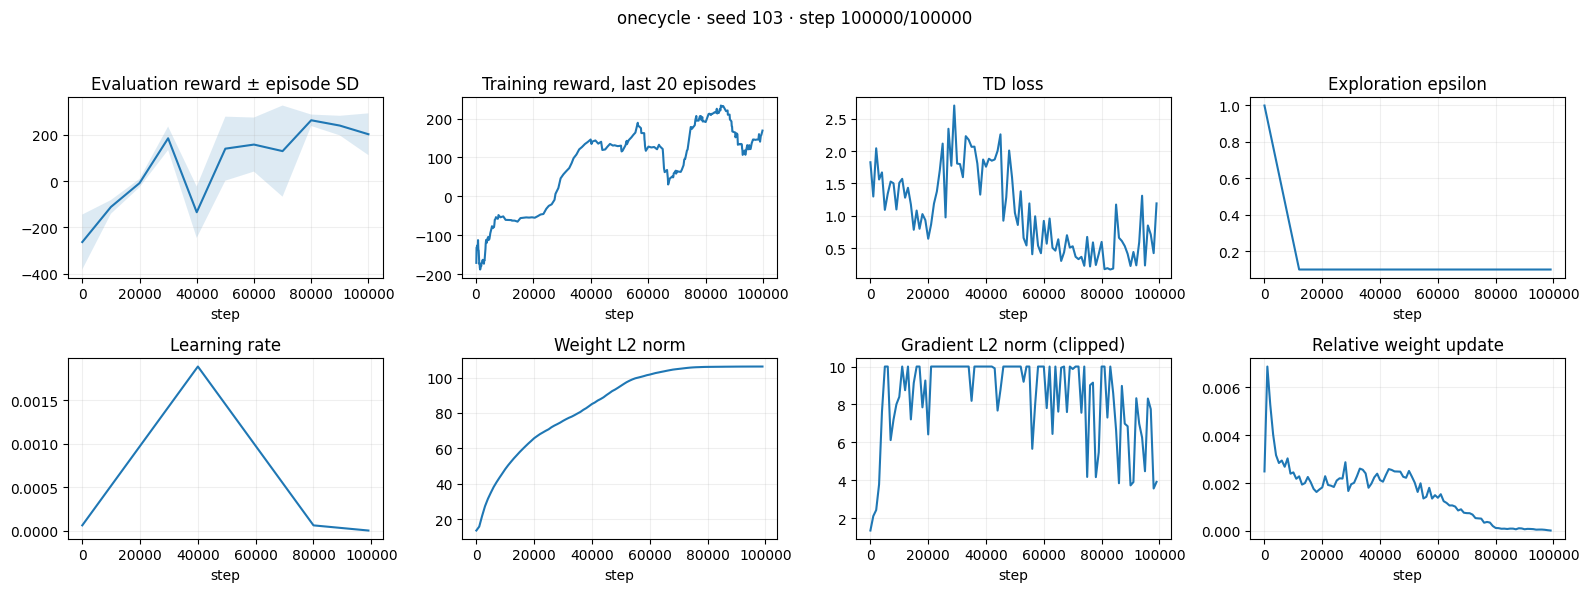

step=10000: reward=-27.8 ± 132.4
step=20000: reward=-0.7 ± 110.1
step=30000: reward=-2.0 ± 52.6
step=40000: reward=7.6 ± 94.7
step=50000: reward=-18.2 ± 21.7
step=60000: reward=-333.7 ± 107.9
step=70000: reward=225.8 ± 77.4
step=80000: reward=184.9 ± 75.6
step=90000: reward=157.5 ± 113.4
step=100000: reward=130.3 ± 108.5
step=0: reward=-565.0 ± 154.9
step=10000: reward=-74.2 ± 39.8
step=20000: reward=-13.0 ± 19.8
step=30000: reward=-34.7 ± 15.3
step=40000: reward=-75.3 ± 174.9
step=50000: reward=11.2 ± 141.5
step=60000: reward=203.4 ± 99.4
step=70000: reward=27.0 ± 186.9
step=80000: reward=245.6 ± 40.5
step=90000: reward=208.6 ± 56.7
step=100000: reward=233.7 ± 25.4
step=0: reward=-263.4 ± 118.9
step=10000: reward=-111.6 ± 29.7
step=20000: reward=-8.4 ± 18.1
step=30000: reward=185.6 ± 50.8
step=40000: reward=-134.4 ± 111.3
step=50000: reward=140.7 ± 138.5
step=60000: reward=158.4 ± 117.0
step=70000: reward=130.1 ± 197.3
step=80000: reward=263.6 ± 24.8
step=90000: reward=240.6 ± 42.4
st

In [ ]:
kind = 'onecycle'
rl_runs[kind] = []
live = LivePlot(rl=True)
for seed in seeds:
    history, result = train_rl(kind, seed, steps=100000, live=live, live_every=2000, video_every=25000)
    rl_runs[kind].append((history.assign(method=kind, seed=seed), result))


In [ ]:
rl_history = pd.concat([h for runs in rl_runs.values() for h, _ in runs], ignore_index=True)
rl_results = pd.DataFrame([r for runs in rl_runs.values() for _, r in runs])
rl_results.groupby("method").agg(reward=("reward_mean", "mean"), between_seed_std=("reward_mean", "std"), seconds=("train_seconds", "mean"))


,reward,between_seed_std,seconds
method,,,
constant,206.297429,54.923953,352.579963
cosine,240.033296,29.208450,362.470625
onecycle,173.536412,37.595634,335.821089


### Награда на test

Для каждого обучающего seed указана средняя награда по 50 эпизодам; итоговое SD считается между тремя агентами.

| LR schedule | Seed 17 | Seed 42 | Seed 103 | Среднее ± SD | Обучение, с |
| --- | --- | --- | --- | --- | --- |
| constant | 143,96 | 227,34 | 247,59 | 206,30 ± 54,92 | 352,58 ± 5,43 |
| cosine | 233,94 | 271,81 | 214,35 | 240,03 ± 29,21 | 362,47 ± 11,21 |
| onecycle | 130,16 | 196,77 | 193,67 | 173,54 ± 37,60 | 335,82 ± 11,01 |

Cosine дает **240,03 ± 29,21**, constant — **206,30 ± 54,92**, 1cycle — **173,54 ± 37,60**. 1cycle уступает обоим контролям на всех трех seed. Этот перенос расписания на DQN не сработал; это не означает, что любой 1cycle в RL будет хуже.

In [ ]:
rl_results.to_csv('rl_results.csv', index=False)

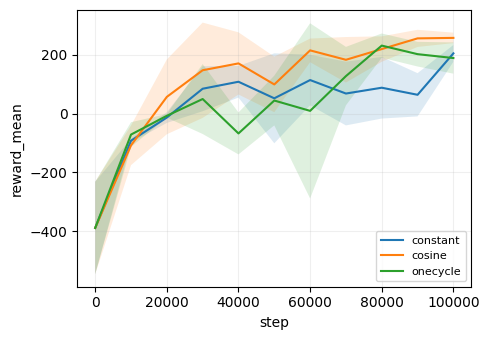

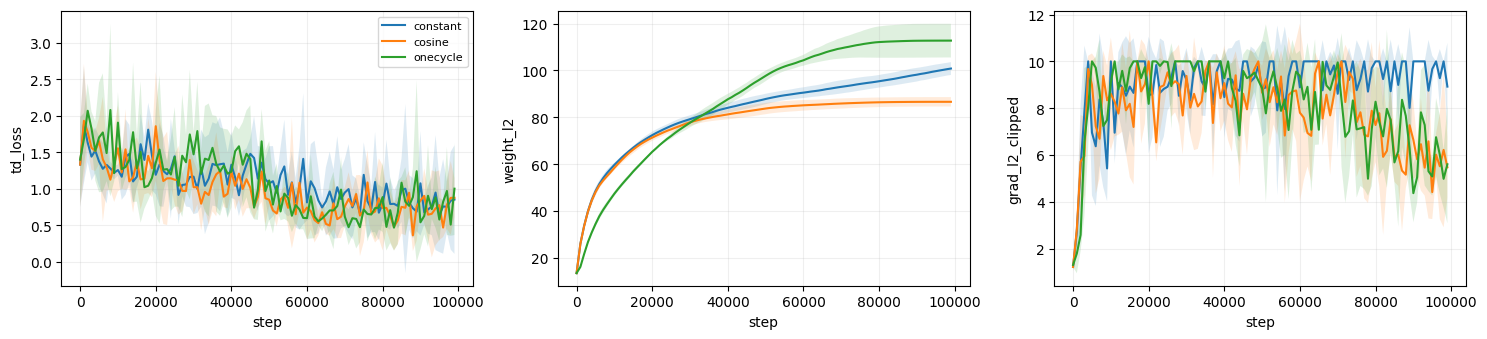

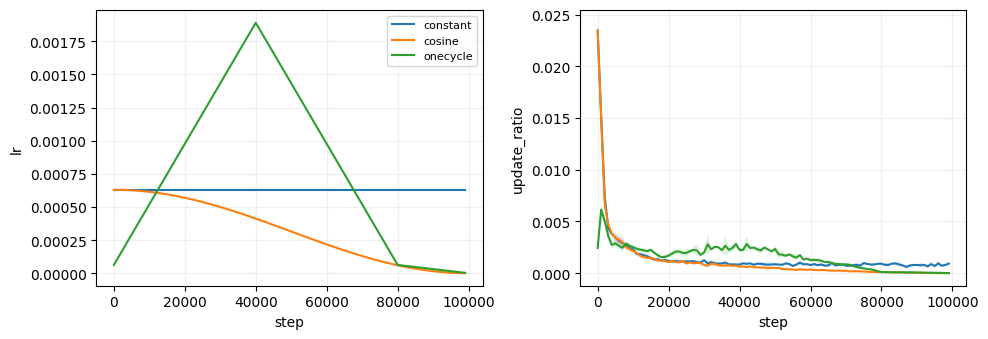

In [ ]:
plot_curves(rl_history, "step", ["reward_mean"])
rl_norms = read_diagnostics("results/rl")
plot_curves(rl_norms, "step", ["td_loss", "weight_l2", "grad_l2_clipped"])
plot_curves(rl_norms, "step", ["lr", "update_ratio"])

### Что видно по loss и нормам

Средние значения на последних 10 000 шагах:

| Режим | TD-loss | ‖W‖₂ | ‖grad‖₂ после clipping | Обновление за 4 шага, % |
| --- | --- | --- | --- | --- |
| constant | 0,800 | 99,54 | 9,66 | 0,08027 |
| cosine | 0,754 | 86,62 | 5,86 | 0,00151 |
| onecycle | 0,754 | 112,73 | 5,82 | 0,00451 |

У cosine и 1cycle TD-loss почти одинаковый, а test reward отличается на 66,50. Значит, низкий TD-loss не гарантирует хорошую policy. Градиент здесь измерен после clipping, обновление — за блок из четырех шагов; сравнивать эти нормы с классификацией нельзя.

Обучение нестабильно: у 1cycle seed=17 eval reward растет до 225,8 на 70 000 шагах, затем падает до 130,3 к концу. Поэтому важно сравнивать несколько seed и заранее определить, какие веса оцениваются.

### Видеоповторы

В ячейках показан последний seed=103. Один удачный ролик не заменяет test: у 1cycle награда в финальном видео равна 256,97, а средняя по 50 эпизодам — 193,67. Все сохраненные ролики лежат в `results/rl/<режим>/<seed>/replays/`.

## Выводы

- **MNIST:** 1cycle сохранил качество при сокращении 85 эпох до 12; измеренное ускорение — 7,01×.
- **CIFAR-10:** при 20 эпохах 1cycle лучше cosine, но отстает от длинных запусков. Подбор улучшил validation, не улучшив test относительно исходного 1cycle.
- **Регуляризация:** большой LR взаимодействует с weight decay, но не заменяет его. Без decay выросли и нормы, и gap.
- **RL:** лучший средний результат у cosine; проверенный 1cycle проиграл обоим контролям на всех трех seed.

Выводы относятся к этим конфигурациям и трем seed. В основных опытах классификации вместе с LR меняется momentum; нормы весов не измеряют плоскость минимума.